# Correlation of pairwise G-Eval judgments

Loads **checkpoint JSONL** from a **single checkpoint leaf** (per–fine-tuned-model layout: `.deepeval/geval_judgment_checkpoints/<model>/`, or flat JSONL in the root). Configure `CHECKPOINT_LEAF_NAME` in the first code cell when several model folders exist.

**Panel (LLM judges only):** for each evaluated model, counts how often each judge (and the full panel) votes *for* that model on comparisons where it appears, **per dimension**. Optional **overall** row pools all dimensions.

**Inter-rater agreement:** **Fleiss’ κ** on nominal votes (`left` / `tie` / `right`) for comparisons where **every** LLM judge has a vote (complete panel), subset to comparisons involving the focal model where applicable.

- **Inter-judge correlation (per dimension):** same pair + dimension across judges — **Spearman** ρ on scores (left = 1, right = −1, tie = 0); only complete comparisons (every judge) are used.
- **Model-specific inter-judge agreement:** for **each judgment leaf** under the checkpoint root (e.g. `gemma-2-9b`, `viking-13b`, …), load that leaf’s JSONL and build one **heatmap + tables** per leaf. **Rows** are summarization ids in the pair; scores are **focal-relative** (+1 = judge prefers focal M, −1 = opponent, 0 = tie) so agreement is not confounded by whether M was placed on the left or right. §1–§4 still use `CHECKPOINT_LEAF_DIR` only; §1b loops **all** leaves.
- **Inter-dimension correlation (per judge):** same pair across criteria — **Spearman** correlation matrix.
- **Summary bar chart:** mean inter-judge Spearman (unique judge pairs) by dimension.

Run with the **repository root** as the working directory. Set `EXCLUDE_API_ERRORS` to drop `[api_error]` rows.

**Plots:** **RdBu_r** heatmaps; set `SAVE_FIGURES = True` to export PNG under `.deepeval/geval_exports/images/`.


In [36]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pairwise_eval.config import EVAL_DIMENSIONS, GEVAL_CHECKPOINT_DIR, LLM_JUDGES, REPO_ROOT
from pairwise_eval.geval_checkpoint import discover_checkpoint_leaf_dirs


def _apply_publication_matplotlib_style() -> None:
    """Sans-serif, high-DPI export defaults, minimal axes (used by heatmaps and bar plots)."""
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.transparent": False,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.04,
            "figure.facecolor": "white",
            "axes.facecolor": "#fafafa",
            "axes.edgecolor": "#2a2a2a",
            "axes.linewidth": 0.9,
            "axes.labelcolor": "#1a1a1a",
            "axes.titlepad": 10,
            "axes.grid": False,
            "text.color": "#1a1a1a",
            "font.family": "sans-serif",
            "font.sans-serif": [
                "Helvetica Neue",
                "Arial",
                "DejaVu Sans",
                "Bitstream Vera Sans",
                "sans-serif",
            ],
            "font.size": 10,
            "axes.titlesize": 12,
            "axes.titleweight": "600",
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "xtick.major.width": 0.5,
            "ytick.major.width": 0.5,
            "legend.frameon": False,
        }
    )


_apply_publication_matplotlib_style()

SAVE_FIGURES = True
FIGURES_DIR = REPO_ROOT / ".deepeval" / "geval_exports" / "images"

CHECKPOINT_ROOT = (
    GEVAL_CHECKPOINT_DIR
    if GEVAL_CHECKPOINT_DIR is not None
    else REPO_ROOT / ".deepeval" / "geval_judgment_checkpoints"
)

# If multiple model subfolders exist, set this to one folder name (e.g. "gemma-2-9b").
# None = use the only leaf if there is exactly one; otherwise raise and list options.
CHECKPOINT_LEAF_NAME: str | None = None


def resolve_checkpoint_leaf(root: Path, leaf_name: str | None) -> Path:
    leaves = discover_checkpoint_leaf_dirs(root)
    if not leaves:
        raise FileNotFoundError(f"No checkpoint JSONL under {root.resolve()}")
    if leaf_name:
        p = (root / leaf_name).resolve()
        if not p.is_dir():
            raise FileNotFoundError(f"CHECKPOINT_LEAF_NAME={leaf_name!r} not found under {root}")
        return p
    if len(leaves) == 1:
        return leaves[0]
    names = [x.name for x in leaves]
    print(
        "WARN: multiple checkpoint leaves — using first:",
        leaves[0].name,
        "| set CHECKPOINT_LEAF_NAME to one of:",
        ", ".join(names),
    )
    return leaves[0]


CHECKPOINT_LEAF_DIR = resolve_checkpoint_leaf(CHECKPOINT_ROOT, CHECKPOINT_LEAF_NAME)

# Impartial / LLM panel only (excludes HUMAN_JUDGES from config).
JUDGES_USED: tuple[str, ...] = tuple(LLM_JUDGES)
DIMENSIONS: tuple[str, ...] = tuple(EVAL_DIMENSIONS)

EXCLUDE_API_ERRORS = True

print("Checkpoint root:", CHECKPOINT_ROOT.resolve())
print("Checkpoint leaf:", CHECKPOINT_LEAF_DIR.resolve())
print("Panel judges (LLM):", list(JUDGES_USED))
print("Dimensions:", list(DIMENSIONS))


WARN: multiple checkpoint leaves — using first: gemma-2-9b | set CHECKPOINT_LEAF_NAME to one of: gemma-2-9b, gemma-2b, llama-2-13b, nb-gpt-j-6b, normistral-11b-apptainer, normistral-11b-long-apptainer, norskgpt-llama3-8b, norwai-mistral-7b, viking-13b
Checkpoint root: /Users/baharehfatemi/Desktop/demokratibasen_checkpoint_selection/.deepeval/geval_judgment_checkpoints
Checkpoint leaf: /Users/baharehfatemi/Desktop/demokratibasen_checkpoint_selection/.deepeval/geval_judgment_checkpoints/gemma-2-9b
Panel judges (LLM): ['gpt-3.5-turbo', 'google/gemini-2.5-flash-preview-05-20', 'anthropic/claude-3-5-haiku-20241022', 'mistral-medium-latest']
Dimensions: ['faithfulness', 'correctness', 'completeness', 'newsworthiness', 'hygiene']


In [37]:
def _safe_stem(judge_id: str) -> str:
    return judge_id.replace("\\", "__").replace("/", "__")


def choice_side_to_score(side: object) -> float:
    if side == "left":
        return 1.0
    if side == "right":
        return -1.0
    return 0.0


def score_preferring_focal(row: pd.Series, focal_id: str) -> float:
    """For model-specific agreement: +1 judge prefers focal M, −1 prefers opponent, 0 tie.

    Unlike ``choice_side_to_score`` (always +1=left), this is invariant when M swaps sides.
    """
    side = row.get("choice_side")
    if side == "tie":
        return 0.0
    if side != "left" and side != "right":
        return 0.0
    L, R = row["left"], row["right"]
    if side == "left":
        return 1.0 if L == focal_id else -1.0
    return 1.0 if R == focal_id else -1.0


def load_judgments_long(
    checkpoint_dir: Path,
    judges: tuple[str, ...],
    dimensions: tuple[str, ...],
    *,
    exclude_api_errors: bool,
) -> pd.DataFrame:
    """One row per judgment with parsed stable-key fields."""
    rows: list[dict] = []
    for judge in judges:
        stem = _safe_stem(judge)
        for dim in dimensions:
            path = checkpoint_dir / f"{stem}__{dim}.jsonl"
            if not path.is_file():
                print(f"missing: {path.name}")
                continue
            with path.open(encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    rec = json.loads(line)
                    key_raw = rec.get("key")
                    if not isinstance(key_raw, str):
                        continue
                    try:
                        k = json.loads(key_raw)
                    except json.JSONDecodeError:
                        continue
                    rationale = str(rec.get("rationale", "") or "")
                    if exclude_api_errors and rationale.startswith("[api_error]"):
                        continue
                    rows.append(
                        {
                            "judge": judge,
                            "dimension": dim,
                            "doc_id": k.get("doc"),
                            "left": k.get("L"),
                            "right": k.get("R"),
                            "pair_hash": k.get("h"),
                            "choice_side": rec.get("choice_side"),
                            "score": choice_side_to_score(rec.get("choice_side")),
                        }
                    )
    return pd.DataFrame(rows)


def comparison_key_inter_judge(row: pd.Series) -> str:
    """Align the same pair + dimension across judges (excludes judge id from key)."""
    payload = {
        "d": row["dimension"],
        "doc": row["doc_id"],
        "h": row["pair_hash"],
        "L": row["left"],
        "R": row["right"],
    }
    return json.dumps(payload, sort_keys=True, separators=(",", ":"))


def comparison_key_inter_dimension(row: pd.Series) -> str:
    """Align the same pair across dimensions for one judge."""
    payload = {
        "doc": row["doc_id"],
        "h": row["pair_hash"],
        "L": row["left"],
        "R": row["right"],
    }
    return json.dumps(payload, sort_keys=True, separators=(",", ":"))


def _short_label(s: str, max_len: int = 32) -> str:
    t = str(s)
    return t if len(t) <= max_len else t[: max_len - 3] + "…"


def _short_judge_label(judge_id: str) -> str:
    """Short labels for LLM judge ids (heatmaps / correlation matrices)."""
    s = str(judge_id)
    if s == "gpt-3.5-turbo":
        return "GPT-3.5"
    if s.startswith("google/") and "gemini" in s:
        return "Gemini 2.5"
    if s.startswith("anthropic/"):
        return "Claude Haiku"
    if s == "mistral-medium-latest":
        return "Mistral"
    return _short_label(s, max_len=18)


def _slug_filename(title: str) -> str:
    s = re.sub(r"[^a-zA-Z0-9]+", "_", title.lower()).strip("_")
    return s[:120] or "figure"


def plot_correlation_matrix(
    cm: pd.DataFrame,
    title: str,
    *,
    vmin: float = -1.0,
    vmax: float = 1.0,
    cmap: str = "RdBu_r",
) -> None:
    """Publication-style heatmap for a symmetric correlation matrix (Pearson / Spearman)."""
    from matplotlib import patheffects as pe

    labels = [_short_judge_label(x) for x in cm.columns]
    mat = cm.to_numpy(dtype=float)
    n = mat.shape[0]
    if n == 0:
        return

    side = float(np.clip(2.35 + n * 0.72, 4.15, 7.4))
    fig, ax = plt.subplots(figsize=(side, side * 0.9))
    im = ax.imshow(
        mat,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        aspect="equal",
        origin="upper",
        interpolation="nearest",
    )
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(labels, rotation=38, ha="right", fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.tick_params(length=0, pad=6)
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.35, zorder=2)

    fs = 10 if n <= 5 else 8 if n >= 8 else 9
    for i in range(n):
        for j in range(n):
            val = mat[i, j]
            if not np.isfinite(val):
                continue
            txt = ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=fs,
                color="#141414",
                fontweight="700" if i == j else "500",
                zorder=3,
            )
            txt.set_path_effects(
                [pe.withStroke(linewidth=3.0, foreground="white", alpha=0.92)]
            )

    ax.set_title(title, fontsize=12, fontweight="600", pad=14, color="#111")
    for spine in ax.spines.values():
        spine.set_visible(False)

    cbar = fig.colorbar(im, ax=ax, fraction=0.032, pad=0.025, shrink=0.82)
    cbar.set_label("Correlation coefficient", fontsize=9, labelpad=10)
    cbar.ax.tick_params(labelsize=8, length=2, width=0.5)
    cbar.outline.set_linewidth(0.45)

    fig.tight_layout()

    if SAVE_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        base = _slug_filename(title)
        fig.savefig(
            FIGURES_DIR / f"{base}.png",
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
    plt.show()

In [38]:
long_df = load_judgments_long(
    CHECKPOINT_LEAF_DIR,
    JUDGES_USED,
    DIMENSIONS,
    exclude_api_errors=EXCLUDE_API_ERRORS,
)
print("rows:", len(long_df))


rows: 2000


## §0b — Comparison-call size (tokens)

> **Find this block:** search `§0b` or `comparison-call tokens`. Run the **next code cell** only after the cell that defines `long_df` has been executed.

Each G-Eval **comparison** sends a **system** message (same default as `pairwise_eval.llm_judge`) plus a **user** message: the dimension template from `DATA_ROOT/prompts/geval/<dimension>.txt` with `{{DOCUMENT}}`, `{{SUMMARY_A}}`, `{{SUMMARY_B}}` filled from the eval JSONL (`source_text`, left/right summaries). That matches `fill_geval_prompt` + the default evaluator system string.

**Token counts are offline only** (rebuild system + user text, then count locally). **No judge inference** and **no calls** to OpenAI / Anthropic / Google / Mistral **APIs** for counting.

| Judge family | How `total_tokens` is computed |
| --- | --- |
| **OpenAI** (`gpt-3.5-turbo`, …) | **`tiktoken.encoding_for_model('gpt-3.5-turbo')`** on system and user separately (same shape as chat). `system_tokens` / `user_tokens` filled; `total_tokens` = sum. |
| **Anthropic** | **`tiktoken` `cl100k_base`** on system and user separately — common **offline** Claude-length estimate (not Anthropic’s hosted `count_tokens`). Routed judge id still maps to `ANTHROPIC_JUDGE_TO_API_MODEL` in the `token_method` label for readability. |
| **Google Gemini** | **`transformers.AutoTokenizer`** on `system + "\n\n" + user` (default HF id **`google/gemma-2-2b-it`**; override **`GEMINI_HF_TOKENIZER`**). This is a **local proxy** length in subwords, not Google’s API tokenizer for `gemini-2.5-flash`. |
| **Mistral** | **`transformers.AutoTokenizer`**: `apply_chat_template` on `[system, user]` (default **`mistralai/Mistral-7B-Instruct-v0.3`**; **`MISTRAL_HF_TOKENIZER`**). Local chat-template token count, not the hosted API bill. |

Install once in the kernel (see `%pip` in the code cell): **`tiktoken`**, **`transformers`**.

Statistics use **every judgment row** in the current `long_df` (after `EXCLUDE_API_ERRORS`), joined to eval JSONL. By default that is `DATA_ROOT/eval/<same name as the judgment leaf>/` via `resolve_eval_dir_for_judgment_leaf`. If that folder is missing (e.g. judgments under `gemma-2-9b` but only `DATA_ROOT/eval/llama-2-13b/` exists here), set **`EVAL_JSONL_LEAF = 'llama-2-13b'`** in the code cell—only when that JSONL is the **same** corpus used when those judgments were written.

The token-counting code calls `pairwise_eval.data.resolve_eval_dir_for_judgment_leaf_notebook`: if there is **exactly one** `DATA_ROOT/eval/<name>/` folder with `*.jsonl` and it does not match the judgment leaf name (e.g. judgments under `gemma-2-9b` but only `DATA_ROOT/eval/llama-2-13b/`), that sole folder is used and a **warning** is emitted—only when you know it is the same corpus. Otherwise set **`EVAL_JSONL_LEAF`** in the code cell to the correct folder name.

Rows whose pair hash does not match the recovered summaries are skipped (unless you set `RELAX_HASH_CHECK = True` after re-generating summaries).


In [29]:
# §0b — comparison-call token counts (per judge). Run after `long_df`, `CHECKPOINT_LEAF_DIR`, `DIMENSIONS` exist.
# Rebuilds the same system + user strings as pairwise G-Eval (template + document + summary A + summary B).
# Token counting is 100% local: no completions and no provider count_tokens / REST calls.

from __future__ import annotations

import hashlib
import os
from typing import Any

import pandas as pd
from IPython.display import display

%pip install -q tiktoken transformers
try:
    import tiktoken
except ImportError as e:
    raise ImportError("Run: pip install tiktoken transformers") from e

from geval_local_judge import fill_geval_prompt, load_geval_template
from pairwise_eval.config import (
    ANTHROPIC_JUDGE_IDS,
    ANTHROPIC_JUDGE_TO_API_MODEL,
    DATA_ROOT,
    GEMINI_JUDGE_IDS,
    GEMINI_JUDGE_TO_API_MODEL,
    MISTRAL_JUDGE_IDS,
    OPENAI_JUDGE_IDS,
)
from pairwise_eval.data import load_eval_jsonl_long_df, resolve_eval_dir_for_judgment_leaf_notebook

_GEVAL_SYSTEM = (
    "You are an evaluator. Follow the user instructions exactly. "
    "When the prompt asks for JSON, reply with only a valid JSON object "
    'with "decision" (A, B, or Tie) and "rationale" (string). '
    "Otherwise, if asked for one word (A, B, or Tie), reply with only that word."
)

_openai_enc = tiktoken.encoding_for_model("gpt-3.5-turbo")
_claudeish_enc = tiktoken.get_encoding("cl100k_base")

_mistral_hf_tok: Any | None = None
_gemini_hf_tok: Any | None = None


def _get_mistral_hf_tokenizer() -> Any:
    global _mistral_hf_tok
    if _mistral_hf_tok is not None:
        return _mistral_hf_tok
    from transformers import AutoTokenizer

    name = os.environ.get("MISTRAL_HF_TOKENIZER", "mistralai/Mistral-7B-Instruct-v0.3").strip()
    if not name:
        name = "mistralai/Mistral-7B-Instruct-v0.3"
    print("Mistral HF tokenizer:", name)
    _mistral_hf_tok = AutoTokenizer.from_pretrained(name)
    return _mistral_hf_tok


def _get_gemini_hf_tokenizer() -> Any:
    global _gemini_hf_tok
    if _gemini_hf_tok is not None:
        return _gemini_hf_tok
    from transformers import AutoTokenizer

    name = os.environ.get("GEMINI_HF_TOKENIZER", "google/gemma-2-2b-it").strip()
    if not name:
        name = "google/gemma-2-2b-it"
    print("Gemini proxy HF tokenizer:", name)
    _gemini_hf_tok = AutoTokenizer.from_pretrained(name)
    return _gemini_hf_tok


def _mistral_total(system: str, user: str) -> int:
    tok = _get_mistral_hf_tokenizer()
    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
    ]
    token_ids = tok.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=False,
        return_tensors=None,
    )
    return len(token_ids)


def _gemini_offline_total(system: str, user: str) -> int:
    tok = _get_gemini_hf_tokenizer()
    combined = f"{system}\n\n{user}"
    return len(tok.encode(combined, add_special_tokens=False))


def _digest(system: str, user: str) -> str:
    h = hashlib.sha256()
    h.update(system.encode("utf-8", errors="surrogatepass"))
    h.update(b"\x00\xff\x00")
    h.update(user.encode("utf-8", errors="surrogatepass"))
    return h.hexdigest()


_tok_mem: dict[tuple[str, ...], dict[str, Any]] = {}


def _count_for_judge(judge_id: str, system: str, user: str) -> dict[str, Any]:
    if judge_id in OPENAI_JUDGE_IDS:
        key = ("openai", _digest(system, user))
        if key not in _tok_mem:
            s = len(_openai_enc.encode(system))
            u = len(_openai_enc.encode(user))
            _tok_mem[key] = {
                "total_tokens": s + u,
                "system_tokens": s,
                "user_tokens": u,
                "method": f"tiktoken.encoding_for_model('gpt-3.5-turbo') [{_openai_enc.name}]",
            }
        return _tok_mem[key]

    if judge_id in ANTHROPIC_JUDGE_IDS:
        api_model = ANTHROPIC_JUDGE_TO_API_MODEL.get(judge_id, judge_id.removeprefix("anthropic/"))
        key = ("anthropic", api_model, _digest(system, user))
        if key not in _tok_mem:
            s = len(_claudeish_enc.encode(system))
            u = len(_claudeish_enc.encode(user))
            _tok_mem[key] = {
                "total_tokens": s + u,
                "system_tokens": s,
                "user_tokens": u,
                "method": (
                    f"offline tiktoken cl100k_base (Claude-length estimate; route label {api_model}; no Anthropic API)"
                ),
            }
        return _tok_mem[key]

    if judge_id in GEMINI_JUDGE_IDS:
        api_model = GEMINI_JUDGE_TO_API_MODEL.get(judge_id, judge_id.removeprefix("google/"))
        key = ("gemini", api_model, _digest(system, user))
        if key not in _tok_mem:
            n = _gemini_offline_total(system, user)
            hf_name = os.environ.get("GEMINI_HF_TOKENIZER", "google/gemma-2-2b-it").strip() or "google/gemma-2-2b-it"
            _tok_mem[key] = {
                "total_tokens": n,
                "system_tokens": pd.NA,
                "user_tokens": pd.NA,
                "method": (
                    f"offline HF.encode(system+blank-line+user) [{hf_name}]; proxy for {api_model}; no Google API"
                ),
            }
        return _tok_mem[key]

    if judge_id in MISTRAL_JUDGE_IDS:
        key = ("mistral", judge_id, _digest(system, user))
        if key not in _tok_mem:
            n = _mistral_total(system, user)
            hf_name = os.environ.get("MISTRAL_HF_TOKENIZER", "mistralai/Mistral-7B-Instruct-v0.3").strip() or (
                "mistralai/Mistral-7B-Instruct-v0.3"
            )
            _tok_mem[key] = {
                "total_tokens": n,
                "system_tokens": pd.NA,
                "user_tokens": pd.NA,
                "method": f"transformers apply_chat_template ({hf_name})",
            }
        return _tok_mem[key]

    raise ValueError(f"Unknown judge id for token counting: {judge_id!r}")


def _pair_body_hash(sumleft: str, sumright: str) -> str:
    blob = (str(sumleft) + "\n---\n" + str(sumright)).encode("utf-8", errors="replace")
    return hashlib.sha256(blob).hexdigest()[:24]


_templates: dict[str, str] = {d: load_geval_template(d) for d in DIMENSIONS}

RELAX_HASH_CHECK = False
EVAL_JSONL_LEAF: str | None = None

if EVAL_JSONL_LEAF:
    _ev_dir = (DATA_ROOT / "eval" / EVAL_JSONL_LEAF.strip()).resolve()
    if not _ev_dir.is_dir():
        raise FileNotFoundError(f"EVAL_JSONL_LEAF={EVAL_JSONL_LEAF!r} is not a directory: {_ev_dir}")
    if not any(_ev_dir.glob("*.jsonl")):
        raise FileNotFoundError(f"No *.jsonl under {_ev_dir}")
    if EVAL_JSONL_LEAF.strip() != CHECKPOINT_LEAF_DIR.name:
        print(
            "WARN: eval JSONL from",
            _ev_dir.name,
            "— judgments from",
            CHECKPOINT_LEAF_DIR.name,
            "(counts are valid only if this is the same eval run / corpus).",
        )
else:
    _ev_dir = resolve_eval_dir_for_judgment_leaf_notebook(CHECKPOINT_LEAF_DIR)
_eval_long = load_eval_jsonl_long_df(_ev_dir)
_summ = _eval_long.set_index(["doc_id", "model_id"])["summary_text"]
_src = _eval_long.groupby("doc_id", sort=False)["source_text"].first()

if _ev_dir.name != CHECKPOINT_LEAF_DIR.name:
    print(
        "NOTE: eval JSONL folder",
        repr(_ev_dir.name),
        "≠ judgment leaf",
        repr(CHECKPOINT_LEAF_DIR.name),
        "— pair_hash checks compare judgment rows to summaries in this eval folder; "
        "if the two runs are not the same corpus, expect all rows to be skipped unless "
        "RELAX_HASH_CHECK = True.",
    )

_rows: list[dict] = []
_mismatch = 0
_missing = 0

for _, r in long_df.iterrows():
    doc = r["doc_id"]
    L, R = r["left"], r["right"]
    dim = r["dimension"]
    try:
        sl = str(_summ.loc[(doc, L)])
        sr = str(_summ.loc[(doc, R)])
    except KeyError:
        _missing += 1
        continue
    h = _pair_body_hash(sl, sr)
    if not RELAX_HASH_CHECK and str(r.get("pair_hash") or "") != h:
        _mismatch += 1
        continue
    try:
        doc_text = str(_src.loc[doc])
    except KeyError:
        _missing += 1
        continue
    user_msg = fill_geval_prompt(_templates[str(dim)], doc_text, sl, sr)
    counts = _count_for_judge(str(r["judge"]), _GEVAL_SYSTEM, user_msg)
    _rows.append(
        {
            "judge": r["judge"],
            "dimension": dim,
            "total_tokens": counts["total_tokens"],
            "user_tokens": counts["user_tokens"],
            "system_tokens": counts["system_tokens"],
            "token_method": counts["method"],
        }
    )

_tok_df = pd.DataFrame(_rows)
if _missing or _mismatch:
    print(f"skipped (missing eval rows): {_missing}; skipped (hash mismatch): {_mismatch}")

if _tok_df.empty:
    print("No token rows built.")
    if _mismatch and not RELAX_HASH_CHECK:
        print(
            "→ Every row was skipped: pair_hash on each judgment row did not match "
            "_pair_body_hash(left_summary, right_summary) from this eval JSONL (same definition as the pipeline). "
            "Summary bytes in DATA_ROOT/eval differ from when judgments were produced "
            "(e.g. sole eval subdir fallback loaded another model's summaries). "
            "Fix: set EVAL_JSONL_LEAF or add DATA_ROOT/eval/<matching leaf>/, or RELAX_HASH_CHECK = True for exploratory counts only."
        )
    elif _missing:
        print(
            "→ Some doc_id / model_id pairs from judgments were missing in the loaded eval long table."
        )
else:
    print("Per-judge `total_tokens` uses the counter described in the markdown cell + `token_method`.")
    print("OpenAI rows also list system/user splits from tiktoken; other providers leave those as NaN.\n")
    for j, sub in _tok_df.groupby("judge", sort=False):
        print(f"  {j}: {sub['token_method'].iloc[0]}")
    print()
    g = _tok_df.groupby("judge", sort=False)["total_tokens"]
    per_judge = pd.DataFrame(
        {
            "n_comparisons": g.size(),
            "mean_tokens": g.mean().round(1),
            "min_tokens": g.min(),
            "max_tokens": g.max(),
        }
    )
    display(per_judge)

    by_jd = (
        _tok_df.groupby(["judge", "dimension"], sort=False)["total_tokens"]
        .agg(n="size", mean="mean", min="min", max="max")
        .round({"mean": 1})
    )
    print("\nBy judge × dimension (mean / min / max on total_tokens):")
    display(by_jd)


FileNotFoundError: No eval data for judgment leaf 'gemma-2-9b': missing or empty /Users/baharehfatemi/Desktop/demokratibasen_checkpoint_selection/Data/eval/gemma-2-9b, and no subfolder under /Users/baharehfatemi/Desktop/demokratibasen_checkpoint_selection/Data/eval matches that name. Available eval subdirs (with *.jsonl): llama-2-13b. Set CHECKPOINT_LEAF_NAME to match one of these, or add Data/eval/gemma-2-9b/*.jsonl.

## 1. Inter-judge correlation (within each dimension)

**Spearman** ρ only. Uses comparisons present for **every** judge in that dimension (inner join on the comparison key). Scores: left = 1, right = −1, tie = 0.

faithfulness: n = 100 paired judgments across all judges
correctness: n = 100 paired judgments across all judges
completeness: n = 100 paired judgments across all judges
newsworthiness: n = 100 paired judgments across all judges
hygiene: n = 100 paired judgments across all judges


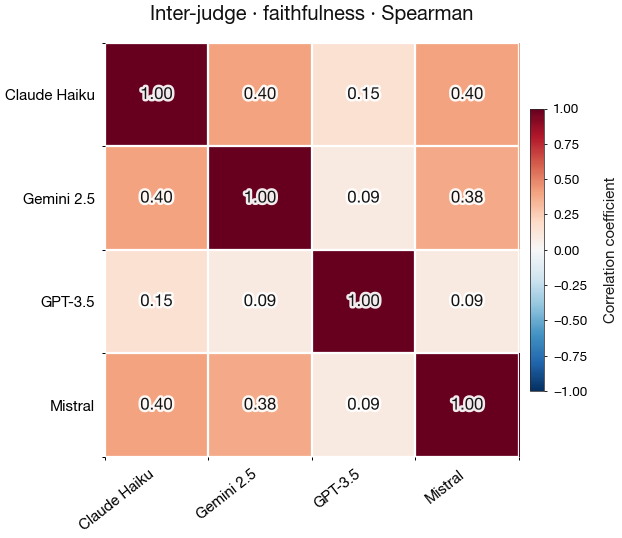

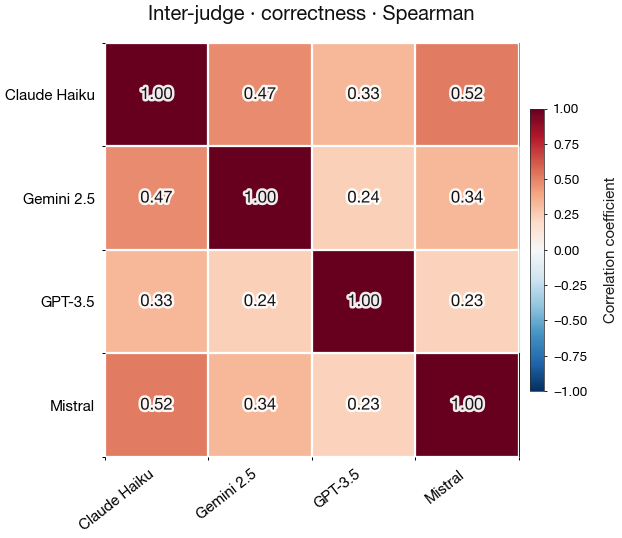

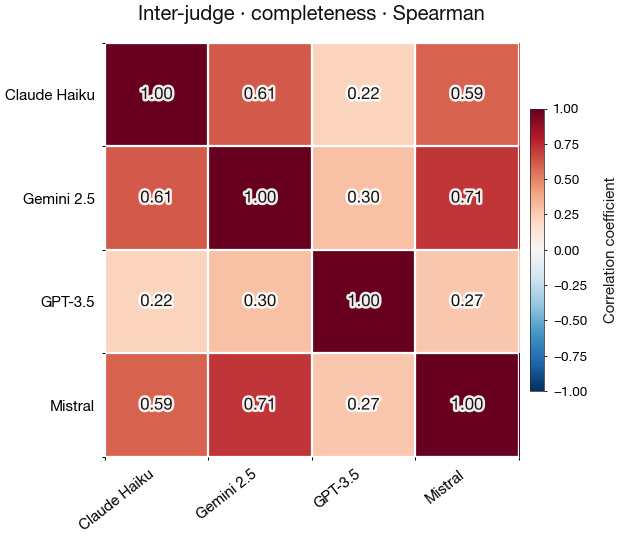

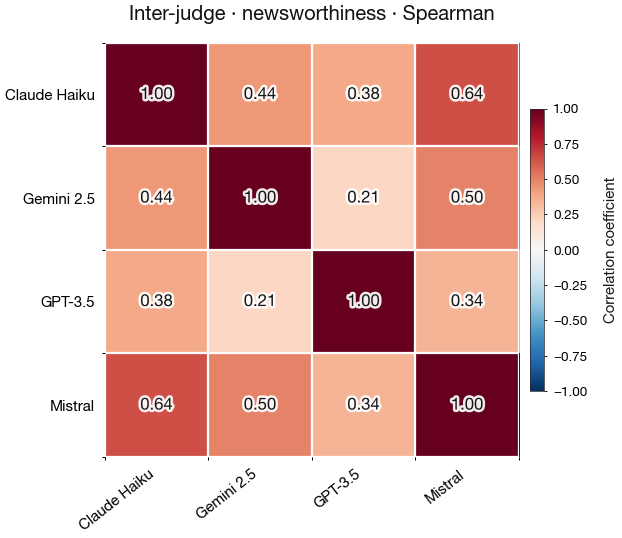

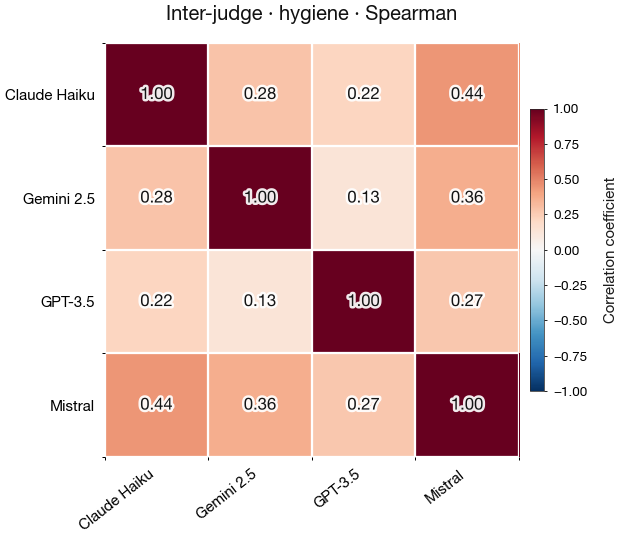

In [31]:
def corr_matrix_for_subset(wide: pd.DataFrame, method: str) -> pd.DataFrame:
    return wide.corr(method=method)


inter_judge_results: dict[str, pd.DataFrame] = {}

for dim in DIMENSIONS:
    sub = long_df.loc[long_df["dimension"] == dim].copy()
    if sub.empty:
        print(f"{dim}: no rows")
        continue
    sub["cmp"] = sub.apply(comparison_key_inter_judge, axis=1)
    wide = sub.pivot_table(index="cmp", columns="judge", values="score", aggfunc="first")
    # keep rows observed by all judges
    wide = wide.dropna(axis=0, how="any")
    n = len(wide)
    print(f"{dim}: n = {n} paired judgments across all judges")
    if n < 3:
        print(f"  skip correlation (need >= 3 rows)")
        continue
    inter_judge_results[dim] = corr_matrix_for_subset(wide, "spearman")

for dim, cm in inter_judge_results.items():
    plot_correlation_matrix(cm, f"Inter-judge · {dim} · Spearman")

## 1a. Inter-judge correlation on **one summarization id** (or a tight substring)

**§1** = all pairwise judgments in the loaded **judgment leaf** (every `left`/`right` id that appears in that leaf’s JSONL).

**§1a** = **same** heatmaps as §1 (per dimension: align comparisons → judge columns → Spearman judge×judge), but only rows where the matchup involves **models you choose**:

- **`INTER_JUDGE_RESTRICT_MODEL_EXACT_ID`** — keep a row if **`left` or `right` equals this string exactly** (use the full summarization id, e.g. `checkpoint-4000-inputs-refs-preds-1000-examples`). That is **one** checkpoint, not “all ~10” in the family.
- **`INTER_JUDGE_RESTRICT_MODEL_SUBSTRING`** — keep a row if **either side’s id contains** this substring (e.g. `"checkpoint-4000"`). Still usually **one** checkpoint if that substring matches only one id in your leaf.

You may set **one or both**; a row is kept if it matches **either** rule.

**`llama-2-13b` is not a `left`/`right` id** in the judgment table — it is the **folder / leaf name** (`CHECKPOINT_LEAF_NAME`). Loading `llama-2-13b` already restricts **which eval run** you see, but **inside** that leaf you still have **many** checkpoint ids (many rows). To restrict to **one** of them, set **exact id** or a **unique substring** for that checkpoint in §1a.

If both filters are empty, §1a is skipped (it would duplicate §1).


In [32]:
# --- §1a: same inter-judge heatmaps as §1, but only comparisons touching a chosen summarization id ---
# Use the full id as it appears in JSONL ``left`` / ``right`` (not the eval folder name like ``llama-2-13b``).
INTER_JUDGE_RESTRICT_MODEL_EXACT_ID: str | None = None  # e.g. "checkpoint-4000-inputs-refs-preds-1000-examples"
# Optional extra filter: substring in ``left`` or ``right`` (used if set, or together with exact).
INTER_JUDGE_RESTRICT_MODEL_SUBSTRING: str | None = None  # e.g. "checkpoint-4000"

_exact = (
    None
    if INTER_JUDGE_RESTRICT_MODEL_EXACT_ID is None
    else str(INTER_JUDGE_RESTRICT_MODEL_EXACT_ID).strip()
)
_sub = (
    None
    if INTER_JUDGE_RESTRICT_MODEL_SUBSTRING is None
    else str(INTER_JUDGE_RESTRICT_MODEL_SUBSTRING).strip()
)
_exact = _exact or None
_sub = _sub or None

if not _exact and not _sub:
    print(
        "§1a skipped: set INTER_JUDGE_RESTRICT_MODEL_EXACT_ID and/or INTER_JUDGE_RESTRICT_MODEL_SUBSTRING "
        "(otherwise identical to §1)."
    )
    inter_judge_one_model_results = {}
else:
    Ls = long_df["left"].astype(str)
    Rs = long_df["right"].astype(str)
    _mask = pd.Series(False, index=long_df.index)
    if _exact:
        _mask = _mask | (Ls == _exact) | (Rs == _exact)
    if _sub:
        _mask = _mask | Ls.str.contains(_sub, case=False, regex=False, na=False) | Rs.str.contains(
            _sub, case=False, regex=False, na=False
        )
    long_df_one_model = long_df.loc[_mask].copy()
    _leaf = CHECKPOINT_LEAF_DIR.name if "CHECKPOINT_LEAF_DIR" in dir() else "?"
    _desc = []
    if _exact:
        _desc.append(f"exact={_exact!r}")
    if _sub:
        _desc.append(f"substring={_sub!r}")
    print(
        f"§1a · leaf {_leaf!r} · filter ({', '.join(_desc)}) → {len(long_df_one_model)} / {len(long_df)} judgment rows"
    )
    if long_df_one_model.empty and len(long_df):
        _ids = sorted(set(long_df["left"].dropna().astype(str)) | set(long_df["right"].dropna().astype(str)))
        print("No rows matched. Sample ``left``/``right`` ids in this leaf:")
        for _s in _ids[:12]:
            print(" ", _s)

    inter_judge_one_model_results: dict[str, pd.DataFrame] = {}
    for dim in DIMENSIONS:
        sub = long_df_one_model.loc[long_df_one_model["dimension"] == dim].copy()
        if sub.empty:
            print(f"{dim}: no rows after filter")
            continue
        sub["cmp"] = sub.apply(comparison_key_inter_judge, axis=1)
        wide = sub.pivot_table(index="cmp", columns="judge", values="score", aggfunc="first")
        wide = wide.dropna(axis=0, how="any")
        n = len(wide)
        print(f"{dim}: n = {n} paired judgments (all judges) after §1a filter")
        if n < 3:
            print("  skip correlation (need >= 3 rows)")
            continue
        inter_judge_one_model_results[dim] = corr_matrix_for_subset(wide, "spearman")

    _short = " & ".join(_desc)
    for dim, cm in inter_judge_one_model_results.items():
        plot_correlation_matrix(cm, f"Inter-judge · {dim} · Spearman · §1a ({_short})")


§1a skipped: set INTER_JUDGE_RESTRICT_MODEL_EXACT_ID and/or INTER_JUDGE_RESTRICT_MODEL_SUBSTRING (otherwise identical to §1).


## 1b. Model-specific inter-judge agreement (Spearman)

**Scope:** one block per **judgment leaf** (subfolder under `CHECKPOINT_ROOT`, e.g. `gemma-2-9b`). Each block loads **that leaf’s** JSONL only.

For each **summarization model** M (any `left` / `right` label in *that* leaf’s data — checkpoint ids and reference), keep only judgments where **M** is in the pair. Within each **dimension**, build a wide table (comparison × judge) using **focal-relative scores**: **+1** if the judge prefers **M**, **−1** if the judge prefers M’s opponent, **0** on ties — so the same “M wins” verdict does not flip sign when M is on the left vs right.

**Summary:** for each (M, dimension), **mean pairwise Spearman** = mean ρ over unique judge pairs (off-diagonals). **Higher** ⇒ judges more often agree on whether **M** was better in those pairs. Fewer than 3 complete comparisons ⇒ NaN in the heatmap.

Exported PNGs (when `SAVE_FIGURES`): `model_specific_mean_inter_judge_spearman__<leaf_slug>.png`.



§1b model-specific heatmap · judgment leaf: gemma-2-9b


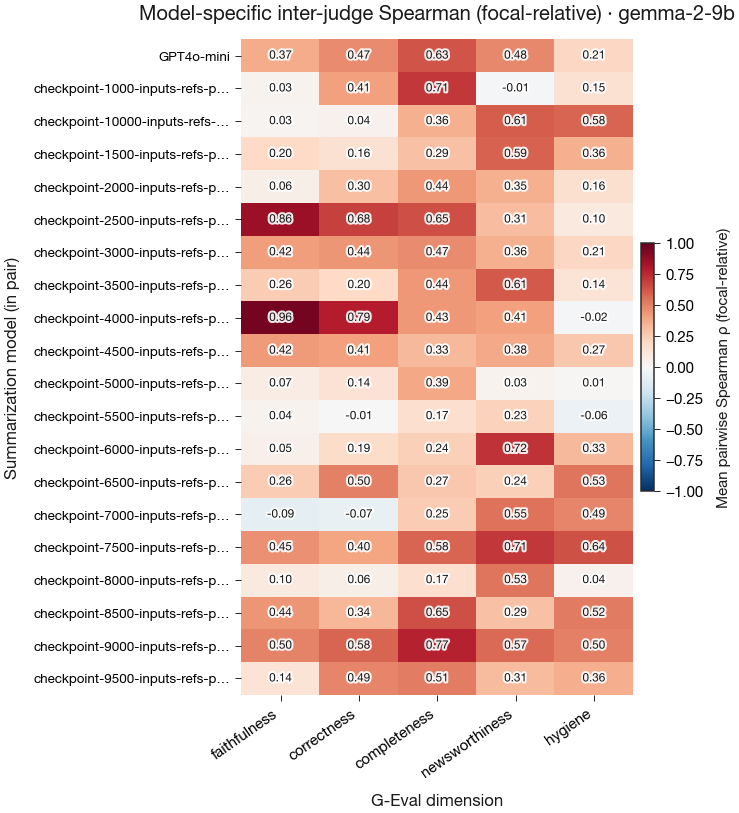


§1b model-specific heatmap · judgment leaf: gemma-2b


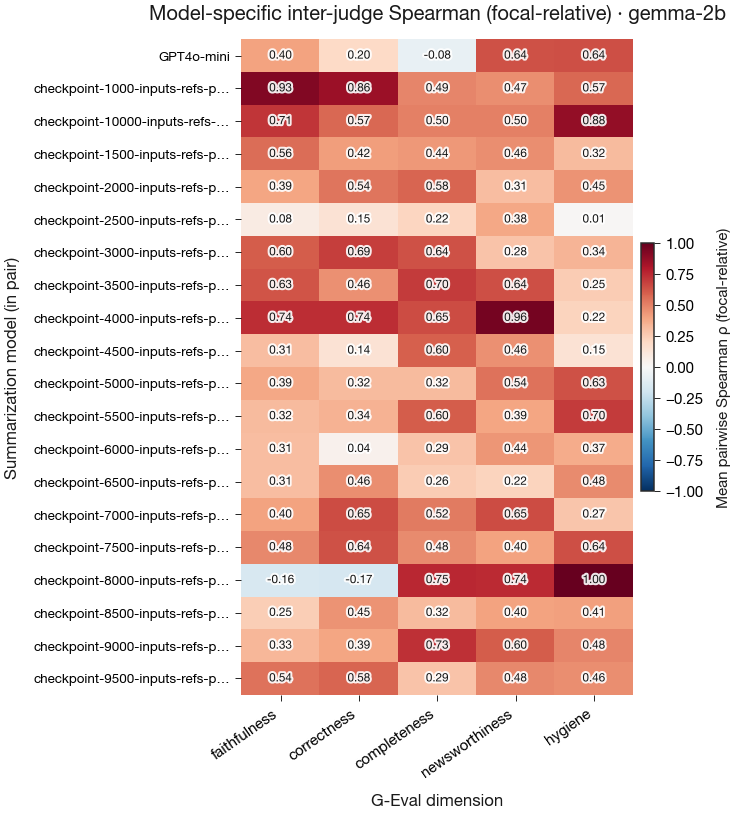


§1b model-specific heatmap · judgment leaf: llama-2-13b


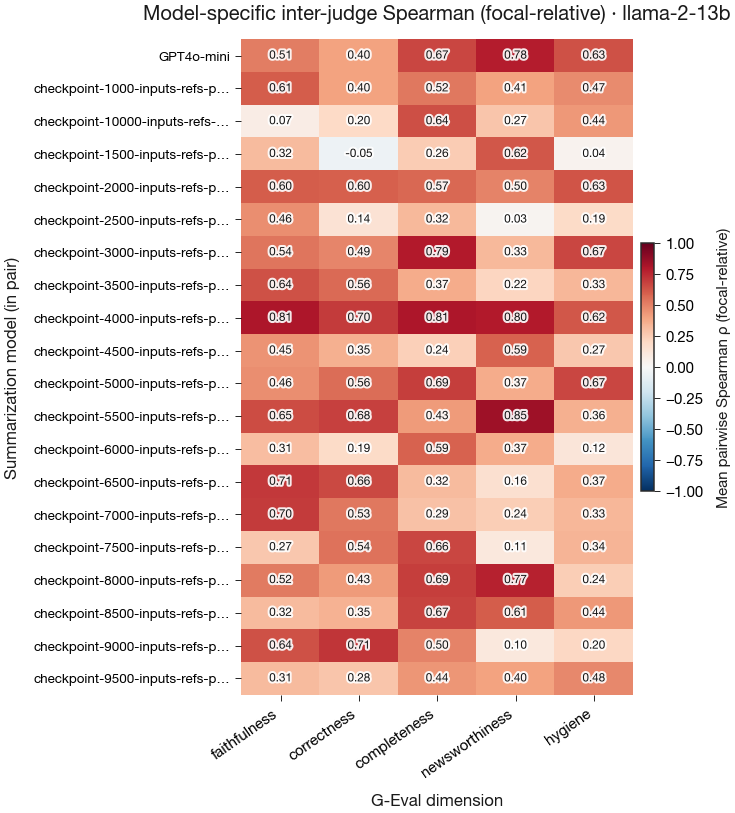


§1b model-specific heatmap · judgment leaf: nb-gpt-j-6b


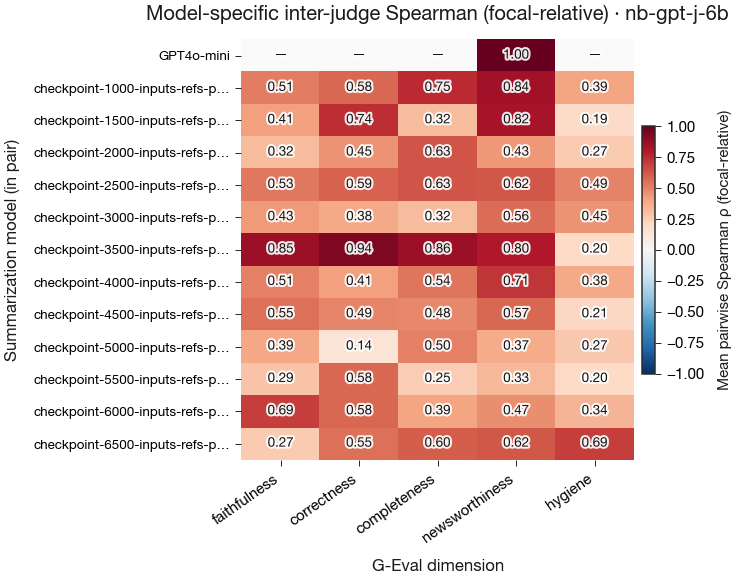


§1b model-specific heatmap · judgment leaf: normistral-11b-apptainer


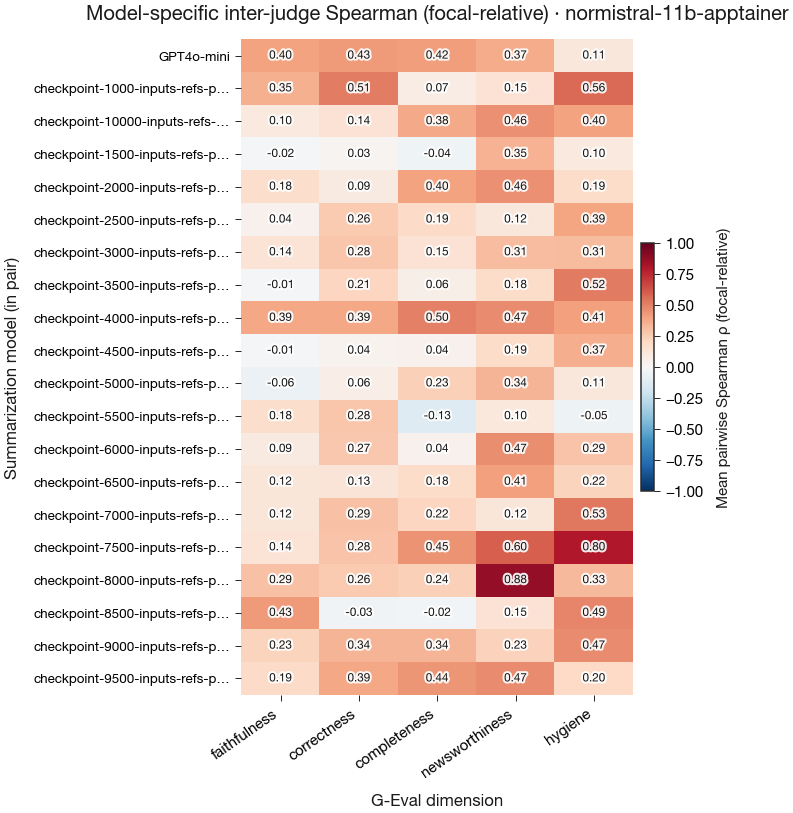


§1b model-specific heatmap · judgment leaf: normistral-11b-long-apptainer


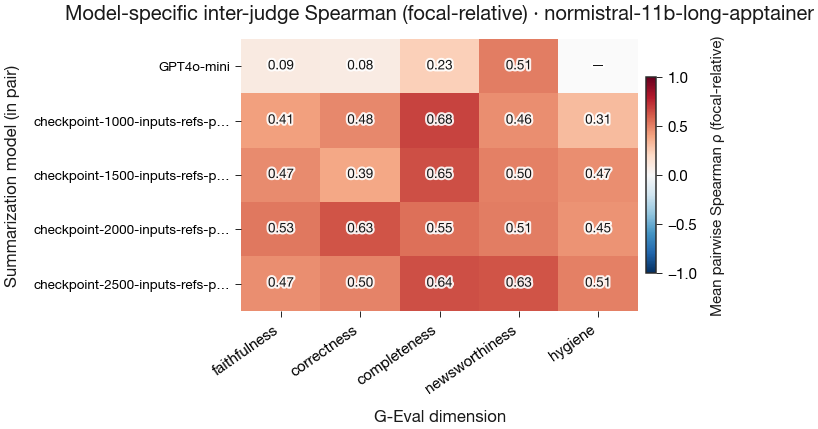


§1b model-specific heatmap · judgment leaf: norskgpt-llama3-8b


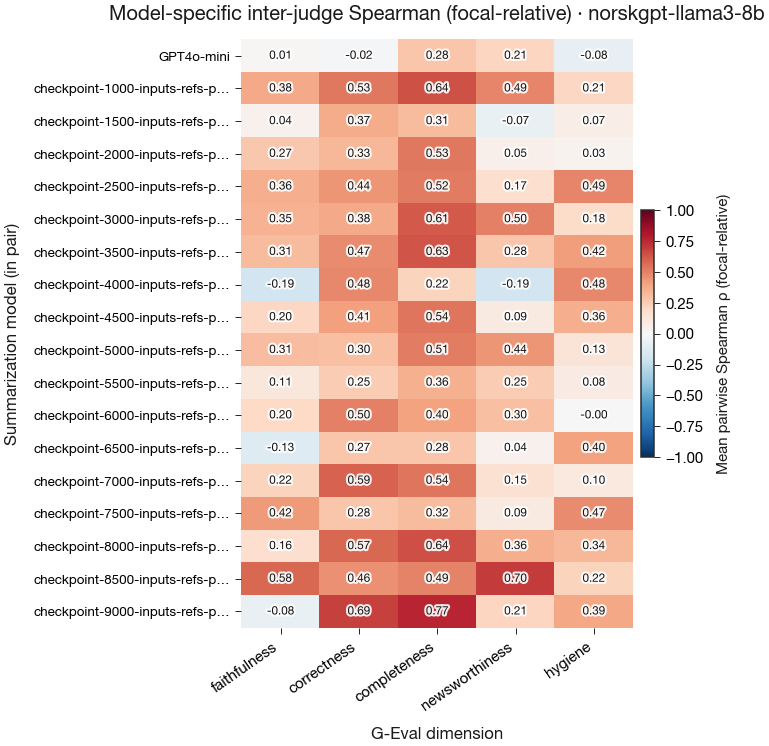


§1b model-specific heatmap · judgment leaf: norwai-mistral-7b


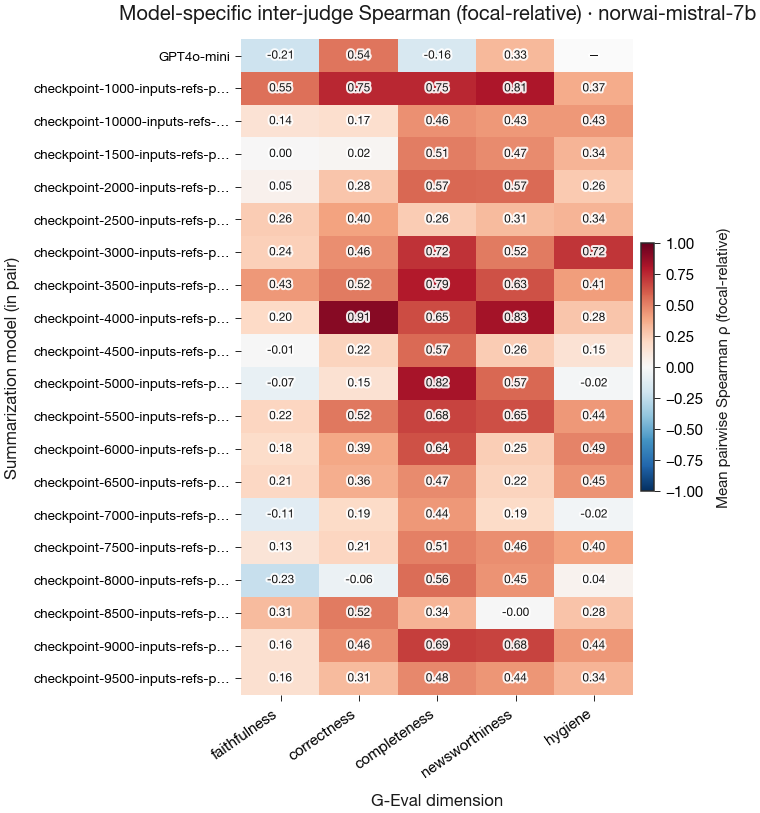


§1b model-specific heatmap · judgment leaf: viking-13b


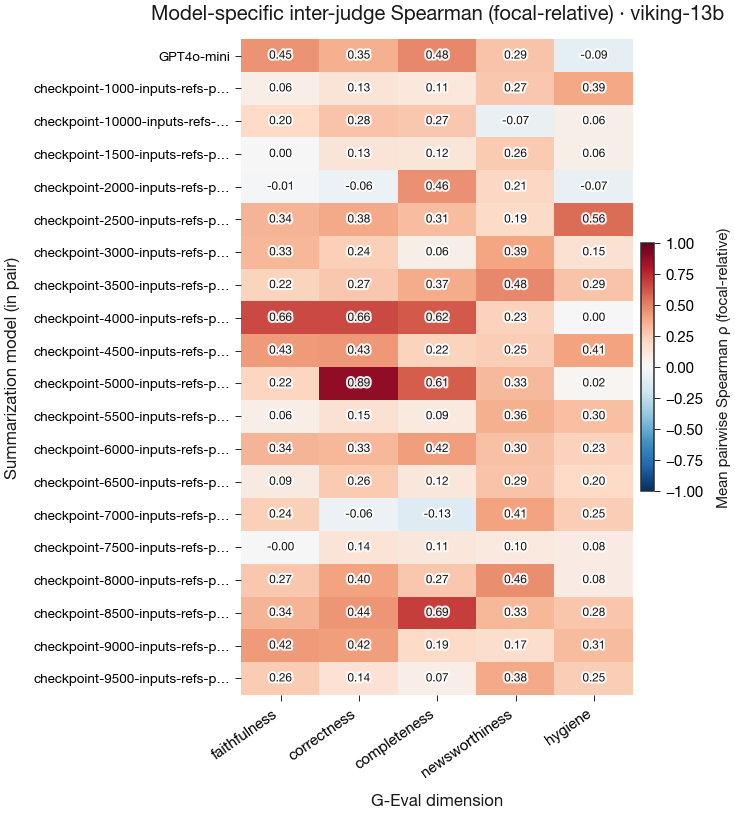

In [33]:
def mean_pairwise_spearman_offdiag(cm: pd.DataFrame) -> float:
    """Mean Spearman ρ over unique judge pairs (upper triangle, excluding diagonal)."""
    judges_l = list(cm.columns)
    pairs: list[float] = []
    for i, a in enumerate(judges_l):
        for b in judges_l[i + 1 :]:
            v = float(cm.loc[a, b])
            if np.isfinite(v):
                pairs.append(v)
    return float(np.mean(pairs)) if pairs else float("nan")


def plot_models_by_dimensions_heatmap(
    mat: pd.DataFrame,
    title: str,
    *,
    vmin: float = -1.0,
    vmax: float = 1.0,
    cbar_label: str = "Mean pairwise Spearman ρ",
    save_filename: str | None = None,
) -> None:
    """Heatmap: rows = models, columns = dimensions (rectangular)."""
    from matplotlib import patheffects as pe

    if mat.empty:
        print("skip heatmap: empty model×dimension table")
        return

    arr = mat.to_numpy(dtype=float)
    n_r, n_c = arr.shape
    fig_w = float(np.clip(1.1 + n_c * 1.05, 5.5, 11.0))
    fig_h = float(np.clip(1.4 + n_r * 0.28, 3.8, 14.0))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(
        arr,
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
        origin="upper",
        interpolation="nearest",
    )
    ax.set_xticks(np.arange(n_c))
    ax.set_yticks(np.arange(n_r))
    ax.set_xticklabels([str(c) for c in mat.columns], rotation=35, ha="right", fontsize=9)
    ax.set_yticklabels([_short_label(str(i)) for i in mat.index], fontsize=8)
    ax.set_xlabel("G-Eval dimension", fontsize=10, labelpad=8)
    ax.set_ylabel("Summarization model (in pair)", fontsize=10, labelpad=8)
    ax.set_title(title, fontsize=12, fontweight="600", pad=12)

    fs = 7 if n_r >= 18 else 8
    for i in range(n_r):
        for j in range(n_c):
            v = arr[i, j]
            if not np.isfinite(v):
                txt = "—"
            else:
                txt = f"{v:.2f}"
            t = ax.text(
                j,
                i,
                txt,
                ha="center",
                va="center",
                fontsize=fs,
                color="#141414",
                fontweight="600",
                zorder=3,
            )
            t.set_path_effects([pe.withStroke(linewidth=2.5, foreground="white", alpha=0.9)])

    for spine in ax.spines.values():
        spine.set_visible(False)
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, shrink=0.72)
    cbar.set_label(cbar_label, fontsize=9, labelpad=8)
    fig.tight_layout()
    if SAVE_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        fname = save_filename or "model_specific_mean_inter_judge_spearman.png"
        fig.savefig(
            FIGURES_DIR / fname,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
    plt.show()


def model_specific_mean_spearman_tables(ldf: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    """Return (pivot_mean, pivot_n, ordered_model_ids) for one judgment long_df."""
    summ_models = sorted(set(ldf["left"].dropna().astype(str)) | set(ldf["right"].dropna().astype(str)))
    model_dim_rows: list[dict] = []
    for model in summ_models:
        for dim in DIMENSIONS:
            sub = ldf.loc[
                (ldf["dimension"] == dim) & ((ldf["left"] == model) | (ldf["right"] == model))
            ].copy()
            if sub.empty:
                continue
            sub["cmp"] = sub.apply(comparison_key_inter_judge, axis=1)
            sub["score_m"] = sub.apply(lambda r: score_preferring_focal(r, model), axis=1)
            wide = sub.pivot_table(index="cmp", columns="judge", values="score_m", aggfunc="first")
            wide = wide.dropna(axis=0, how="any")
            n = len(wide)
            if n < 3:
                model_dim_rows.append(
                    {
                        "model": model,
                        "dimension": dim,
                        "mean_pairwise_spearman": float("nan"),
                        "n_complete_comparisons": n,
                    }
                )
                continue
            cm = corr_matrix_for_subset(wide, "spearman")
            model_dim_rows.append(
                {
                    "model": model,
                    "dimension": dim,
                    "mean_pairwise_spearman": mean_pairwise_spearman_offdiag(cm),
                    "n_complete_comparisons": n,
                }
            )
    model_dim_df = pd.DataFrame(model_dim_rows)
    if model_dim_df.empty:
        empty = pd.DataFrame()
        return empty, empty, summ_models
    pivot_mean = model_dim_df.pivot_table(
        index="model", columns="dimension", values="mean_pairwise_spearman", aggfunc="first"
    )
    pivot_mean = pivot_mean.reindex(index=summ_models, columns=list(DIMENSIONS))
    pivot_n = model_dim_df.pivot_table(
        index="model", columns="dimension", values="n_complete_comparisons", aggfunc="first"
    ).reindex(index=summ_models, columns=list(DIMENSIONS))
    return pivot_mean, pivot_n, summ_models


_judgment_leaves = discover_checkpoint_leaf_dirs(CHECKPOINT_ROOT)
if not _judgment_leaves:
    print("No checkpoint leaves for model-specific section.")
else:
    for leaf_dir in _judgment_leaves:
        tag = leaf_dir.name
        print(f"\n§1b model-specific heatmap · judgment leaf: {tag}")
        ldf = load_judgments_long(
            leaf_dir, JUDGES_USED, DIMENSIONS, exclude_api_errors=EXCLUDE_API_ERRORS
        )
        pivot_mean, pivot_n, _ = model_specific_mean_spearman_tables(ldf)
        if pivot_mean.empty:
            print(f"  {tag}: no model-specific rows (empty).")
            continue
        slug = _slug_filename(tag)
        plot_models_by_dimensions_heatmap(
            pivot_mean,
            f"Model-specific inter-judge Spearman (focal-relative) · {tag}",
            cbar_label="Mean pairwise Spearman ρ (focal-relative)",
            save_filename=f"model_specific_mean_inter_judge_spearman__{slug}.png",
        )


In [46]:
# DEBUG — nb-gpt-j-6b only: GPT4o-mini focal row (why each dimension has a value or is blank)
from pairwise_eval.config import REFERENCE_SUMMARY_MODEL_ID

_dbg_leaf = CHECKPOINT_ROOT / "norwai-mistral-7b"
_dbg_M = REFERENCE_SUMMARY_MODEL_ID
_ldf_dbg = load_judgments_long(
    _dbg_leaf, JUDGES_USED, DIMENSIONS, exclude_api_errors=EXCLUDE_API_ERRORS
)

print(f"DEBUG leaf: {_dbg_leaf.name} | focal M: {_dbg_M!r}\n")
for _dim in DIMENSIONS:
    _sub = _ldf_dbg.loc[
        (_ldf_dbg["dimension"] == _dim)
        & ((_ldf_dbg["left"] == _dbg_M) | (_ldf_dbg["right"] == _dbg_M))
    ].copy()
    if _sub.empty:
        print(f"  {_dim}: no rows with M in pair")
        continue
    _sub["cmp"] = _sub.apply(comparison_key_inter_judge, axis=1)
    _sub["score_m"] = _sub.apply(lambda r, m=_dbg_M: score_preferring_focal(r, m), axis=1)
    _wide = _sub.pivot_table(index="cmp", columns="judge", values="score_m", aggfunc="first")
    _n_before = len(_wide)
    _wide = _wide.dropna(axis=0, how="any")
    _n = len(_wide)
    _std = _wide.std(axis=0, ddof=0)
    print(f"  {_dim}: n_rows_pivot={_n_before} n_complete_panel={_n} std(score_m)={_std.to_dict()}")
    if _n >= 3:
        _cm = _wide.corr(method="spearman")
        print(f"         Spearman corr has any NaN: {_cm.isna().any().any()} | NaN cells: {int(_cm.isna().sum().sum())}")


DEBUG leaf: norwai-mistral-7b | focal M: 'GPT4o-mini'

  faithfulness: n_rows_pivot=14 n_complete_panel=14 std(score_m)={'anthropic/claude-3-5-haiku-20241022': 0.0, 'google/gemini-2.5-flash-preview-05-20': 0.5933302759227196, 'gpt-3.5-turbo': 0.823754471047914, 'mistral-medium-latest': 0.25753937681885636}
         Spearman corr has any NaN: True | NaN cells: 7
  correctness: n_rows_pivot=14 n_complete_panel=14 std(score_m)={'anthropic/claude-3-5-haiku-20241022': 0.0, 'google/gemini-2.5-flash-preview-05-20': 0.5890150893739516, 'gpt-3.5-turbo': 0.823754471047914, 'mistral-medium-latest': 0.5150787536377127}
         Spearman corr has any NaN: True | NaN cells: 7
  completeness: n_rows_pivot=14 n_complete_panel=14 std(score_m)={'anthropic/claude-3-5-haiku-20241022': 0.0, 'google/gemini-2.5-flash-preview-05-20': 0.6998542122237653, 'gpt-3.5-turbo': 0.82065180664829, 'mistral-medium-latest': 0.5150787536377126}
         Spearman corr has any NaN: True | NaN cells: 7
  newsworthiness: n_ro

## 1b′. Model-specific agreement via **Bradley–Terry ranks**

Same **scope** as §1b: one judgment leaf, focal summarization model *M* appears in the pair, and we keep only comparisons with a **full judge panel** (same `cmp` key as before). For each *(M, dimension)* we **do not** use focal-relative ±1 scores. Instead, each judge’s outcomes on that comparison set define a **Bradley–Terry** win matrix over all checkpoints that appear (including *M*). We fit BT with **β*M* = 0** (focal anchored), map **θ = exp(β)** to **average ranks** over models (higher θ ⇒ numerically smaller rank = “stronger”), then take **Spearman** correlation between judges’ rank columns and the **mean over judge pairs** (off-diagonal), same summary style as §1b. **Runtime:** this fits one BT per *(M, dimension, judge)* on the slice, so it is typically slower than §1b’s correlation-on-scores loop.


§1b′ model-specific heatmap (BT ranks) · judgment leaf: gemma-2-9b


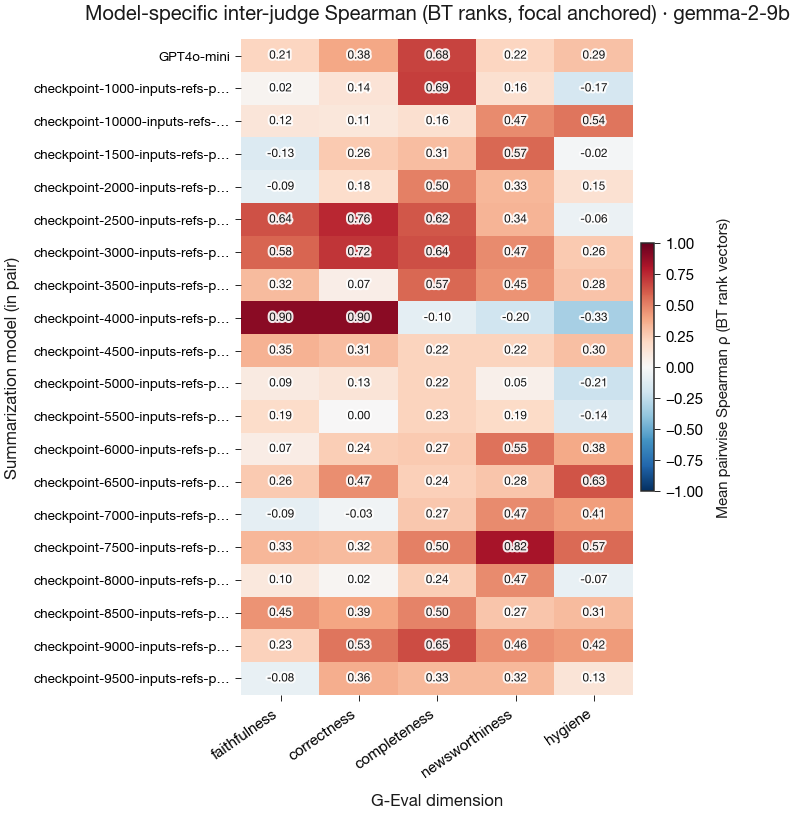


§1b′ model-specific heatmap (BT ranks) · judgment leaf: gemma-2b


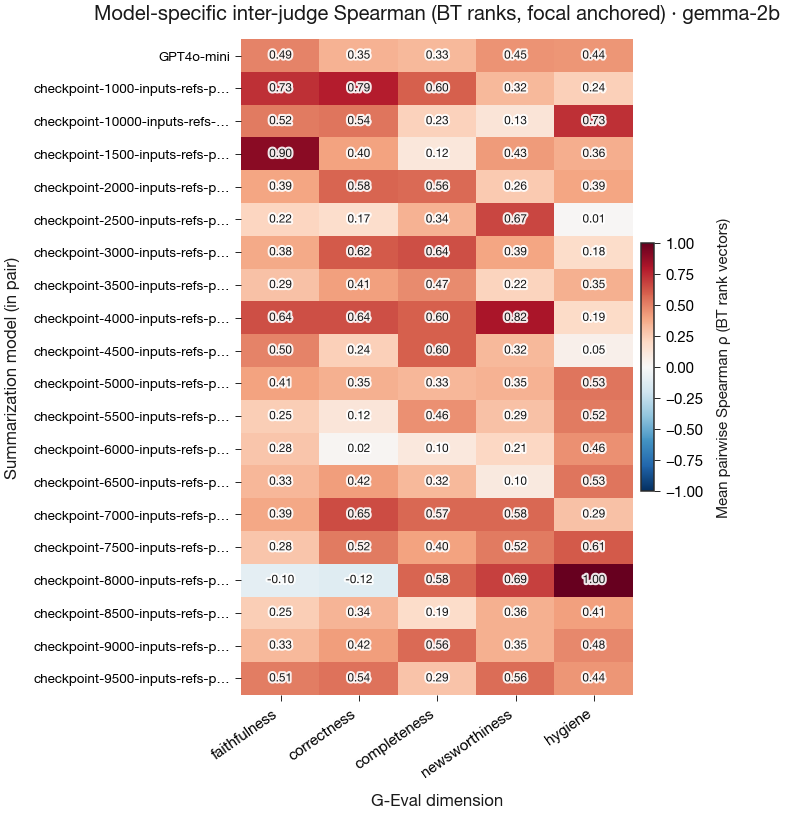


§1b′ model-specific heatmap (BT ranks) · judgment leaf: llama-2-13b


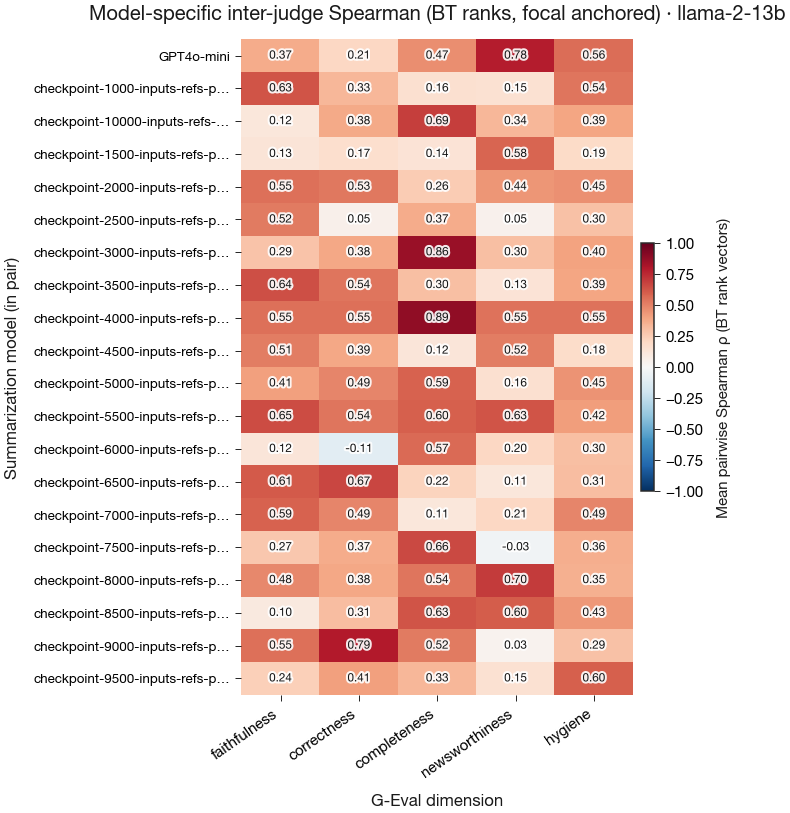


§1b′ model-specific heatmap (BT ranks) · judgment leaf: nb-gpt-j-6b


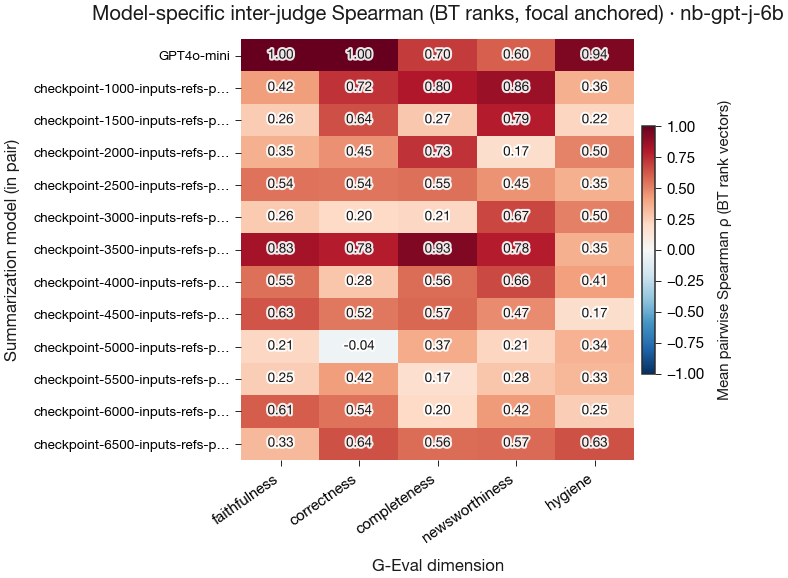


§1b′ model-specific heatmap (BT ranks) · judgment leaf: normistral-11b-apptainer


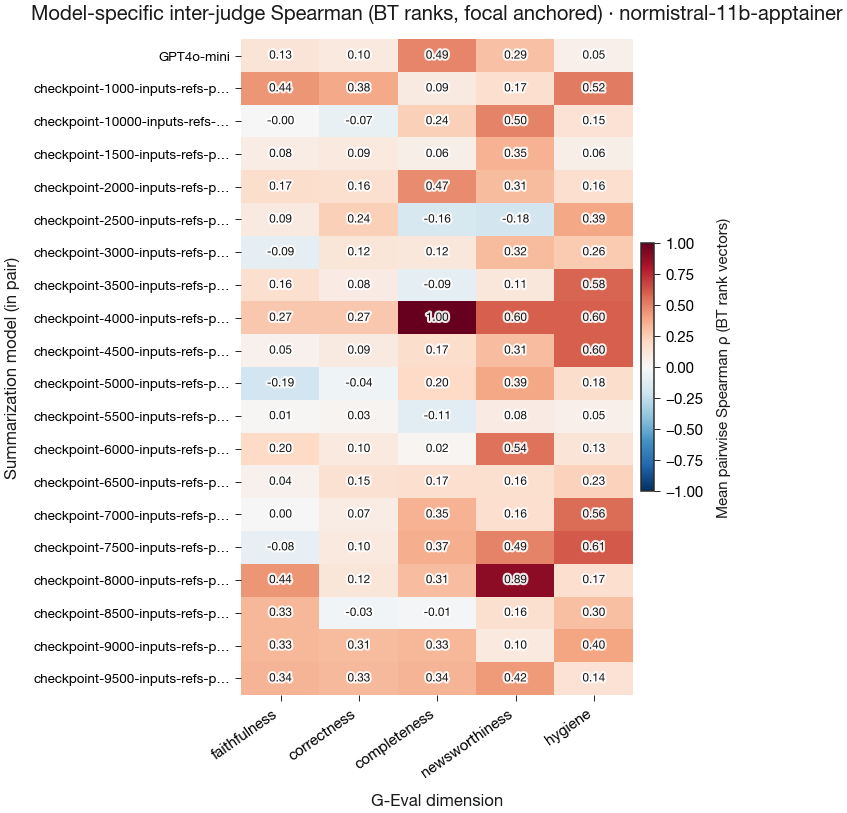


§1b′ model-specific heatmap (BT ranks) · judgment leaf: normistral-11b-long-apptainer


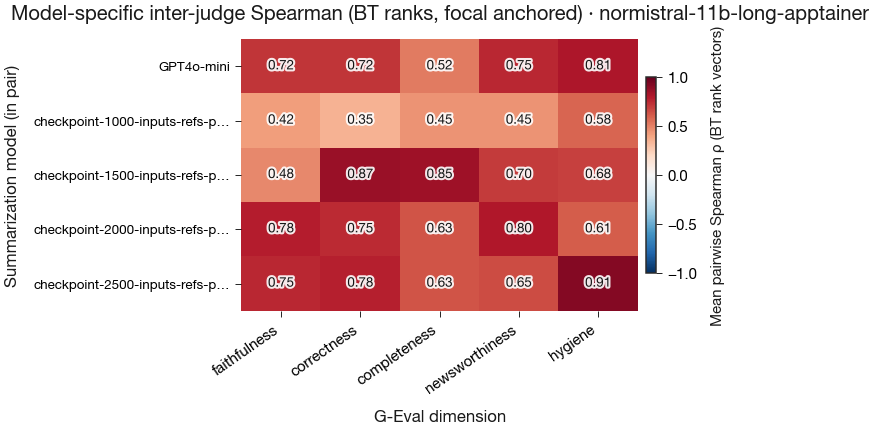


§1b′ model-specific heatmap (BT ranks) · judgment leaf: norskgpt-llama3-8b


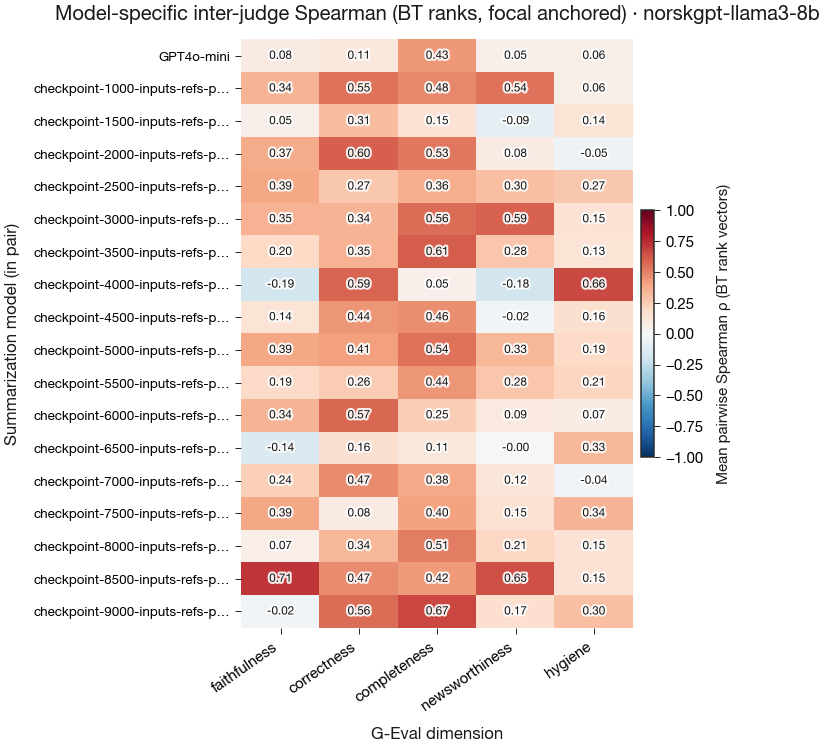


§1b′ model-specific heatmap (BT ranks) · judgment leaf: norwai-mistral-7b


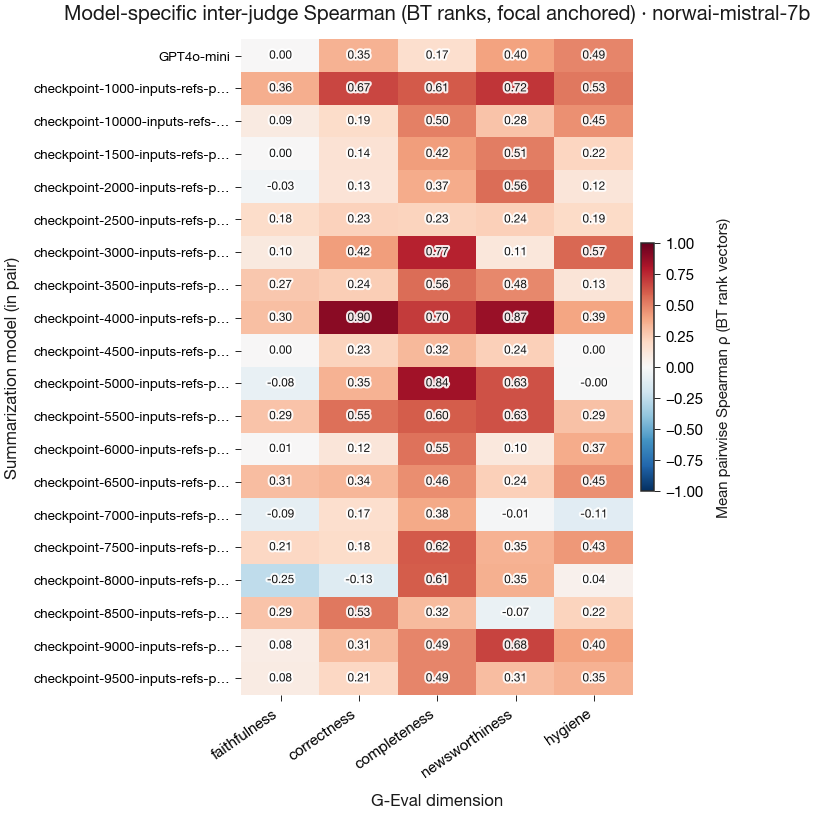


§1b′ model-specific heatmap (BT ranks) · judgment leaf: viking-13b


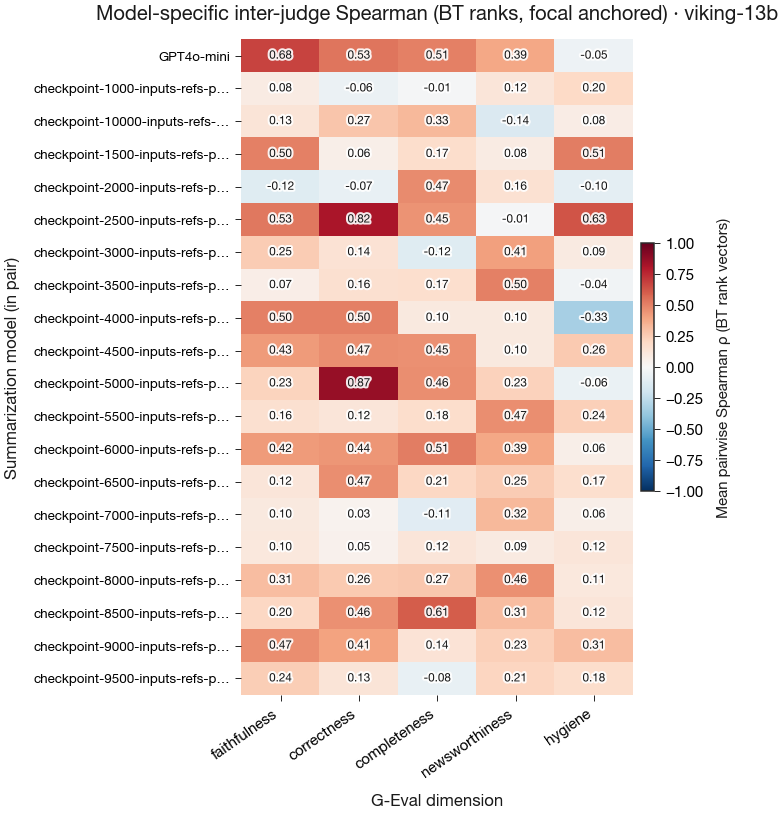

In [47]:
from scipy import stats

from pairwise_eval.bradley_terry import fit_bradley_terry, win_matrix_from_geval


def _chosen_for_bt(row: pd.Series) -> object:
    side = row.get("choice_side")
    if side == "tie":
        return float("nan")
    if side == "left":
        return row["left"]
    if side == "right":
        return row["right"]
    return float("nan")


def model_specific_bt_rank_spearman_tables(
    ldf: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    """Per (focal M, dimension): BT on the §1b complete-panel slice (M anchored); Spearman on θ-rank vectors."""
    summ_models = sorted(set(ldf["left"].dropna().astype(str)) | set(ldf["right"].dropna().astype(str)))
    rows_out: list[dict] = []
    for model in summ_models:
        for dim in DIMENSIONS:
            sub = ldf.loc[
                (ldf["dimension"] == dim) & ((ldf["left"] == model) | (ldf["right"] == model))
            ].copy()
            if sub.empty:
                continue
            sub["cmp"] = sub.apply(comparison_key_inter_judge, axis=1)
            wide_panel = sub.pivot_table(index="cmp", columns="judge", values="score", aggfunc="first")
            wide_panel = wide_panel.dropna(axis=0, how="any")
            judges_here = [j for j in JUDGES_USED if j in wide_panel.columns]
            if len(judges_here) != len(JUDGES_USED):
                rows_out.append(
                    {
                        "model": model,
                        "dimension": dim,
                        "mean_pairwise_spearman": float("nan"),
                        "n_complete_comparisons": int(len(wide_panel)),
                    }
                )
                continue
            n = len(wide_panel)
            if n < 3:
                rows_out.append(
                    {
                        "model": model,
                        "dimension": dim,
                        "mean_pairwise_spearman": float("nan"),
                        "n_complete_comparisons": n,
                    }
                )
                continue
            cmps = set(wide_panel.index)
            sub_c = sub.loc[sub["cmp"].isin(cmps)].drop_duplicates(subset=["cmp", "judge"], keep="first")
            models_u = sorted(
                set(sub_c["left"].dropna().astype(str)) | set(sub_c["right"].dropna().astype(str))
            )
            if model not in models_u or len(models_u) < 2:
                rows_out.append(
                    {
                        "model": model,
                        "dimension": dim,
                        "mean_pairwise_spearman": float("nan"),
                        "n_complete_comparisons": n,
                    }
                )
                continue
            ref_idx = models_u.index(model)
            rank_by_judge: dict[str, pd.Series] = {}
            failed = False
            for j in judges_here:
                tbl_j = sub_c.loc[sub_c["judge"] == j, ["left", "right", "choice_side"]].copy()
                if len(tbl_j) != n:
                    failed = True
                    break
                tbl_j["chosen"] = tbl_j.apply(_chosen_for_bt, axis=1)
                w = win_matrix_from_geval(tbl_j, models_u)
                if float((w + w.T).sum()) <= 0:
                    failed = True
                    break
                beta, _res = fit_bradley_terry(w, ref_idx=ref_idx)
                if not np.all(np.isfinite(beta)):
                    failed = True
                    break
                theta = np.exp(np.asarray(beta, dtype=float))
                rk = stats.rankdata(-theta, method="average")
                rank_by_judge[j] = pd.Series(rk, index=models_u, dtype=float)
            if failed or len(rank_by_judge) != len(judges_here):
                rows_out.append(
                    {
                        "model": model,
                        "dimension": dim,
                        "mean_pairwise_spearman": float("nan"),
                        "n_complete_comparisons": n,
                    }
                )
                continue
            rank_df = pd.DataFrame(rank_by_judge).reindex(columns=list(judges_here))
            cm = corr_matrix_for_subset(rank_df, "spearman")
            rows_out.append(
                {
                    "model": model,
                    "dimension": dim,
                    "mean_pairwise_spearman": mean_pairwise_spearman_offdiag(cm),
                    "n_complete_comparisons": n,
                }
            )
    model_dim_df = pd.DataFrame(rows_out)
    if model_dim_df.empty:
        return pd.DataFrame(), pd.DataFrame(), summ_models
    pivot_mean = model_dim_df.pivot_table(
        index="model", columns="dimension", values="mean_pairwise_spearman", aggfunc="first"
    ).reindex(index=summ_models, columns=list(DIMENSIONS))
    pivot_n = model_dim_df.pivot_table(
        index="model", columns="dimension", values="n_complete_comparisons", aggfunc="first"
    ).reindex(index=summ_models, columns=list(DIMENSIONS))
    return pivot_mean, pivot_n, summ_models


_judgment_leaves_bt = discover_checkpoint_leaf_dirs(CHECKPOINT_ROOT)
if not _judgment_leaves_bt:
    print("No checkpoint leaves for BT-rank model-specific section.")
else:
    for leaf_dir in _judgment_leaves_bt:
        tag = leaf_dir.name
        print(f"\n§1b′ model-specific heatmap (BT ranks) · judgment leaf: {tag}")
        ldf_bt = load_judgments_long(
            leaf_dir, JUDGES_USED, DIMENSIONS, exclude_api_errors=EXCLUDE_API_ERRORS
        )
        pivot_mean_bt, pivot_n_bt, _ = model_specific_bt_rank_spearman_tables(ldf_bt)
        if pivot_mean_bt.empty:
            print(f"  {tag}: no model-specific rows (empty).")
            continue
        slug = _slug_filename(tag)
        plot_models_by_dimensions_heatmap(
            pivot_mean_bt,
            f"Model-specific inter-judge Spearman (BT ranks, focal anchored) · {tag}",
            cbar_label="Mean pairwise Spearman ρ (BT rank vectors)",
            save_filename=f"model_specific_bt_rank_mean_inter_judge_spearman__{slug}.png",
        )


## 1c. Inter-judge agreement on **checkpoint ranking from Bradley–Terry θ**

For a G-Eval **export** folder (same layout as `export_full_run`, e.g. `norwai-mistral-7b` under `REPO_ROOT/.deepeval/<export-name>/`):

- Load **`tables/bradley_terry_long.csv`** (θ already from BT fit of pairwise G-Eval per judge × dimension).
- Restrict to **fine-tuned checkpoint** ids (optional: drop reference `GPT4o-mini`).
- For each **dimension** and each **judge**, **rank** checkpoints by **θ** (higher θ → better rank, ties averaged).
- **Spearman** correlation of those **rank** columns (same checkpoint order as rows) = how similarly judges order checkpoints. **One figure:** a **3×2** grid of **judge × judge** heatmaps (one subplot per dimension; short judge names on the axes).

Configure **`BT_RANK_EXPORT_LEAF`** below. Set **`BT_RANK_INCLUDE_REFERENCE = True`** to also rank the reference in the list. When `SAVE_FIGURES` is on, exports **`bt_theta_rank_inter_judge_spearman_grid__<leaf>.png`** under `.deepeval/geval_exports/images/`.


BT rank agreement: normistral-11b-long-apptainer | judges: ['gpt-3.5-turbo', 'google/gemini-2.5-flash-preview-05-20', 'anthropic/claude-3-5-haiku-20241022', 'mistral-medium-latest'] | dimensions: ['faithfulness', 'correctness', 'completeness', 'newsworthiness', 'hygiene']
  faithfulness: n_checkpoints=5  Spearman of BT-based ranks (any NaN in off-diag: False)
  correctness: n_checkpoints=5  Spearman of BT-based ranks (any NaN in off-diag: False)
  completeness: n_checkpoints=5  Spearman of BT-based ranks (any NaN in off-diag: False)
  newsworthiness: n_checkpoints=5  Spearman of BT-based ranks (any NaN in off-diag: False)
  hygiene: n_checkpoints=5  Spearman of BT-based ranks (any NaN in off-diag: False)


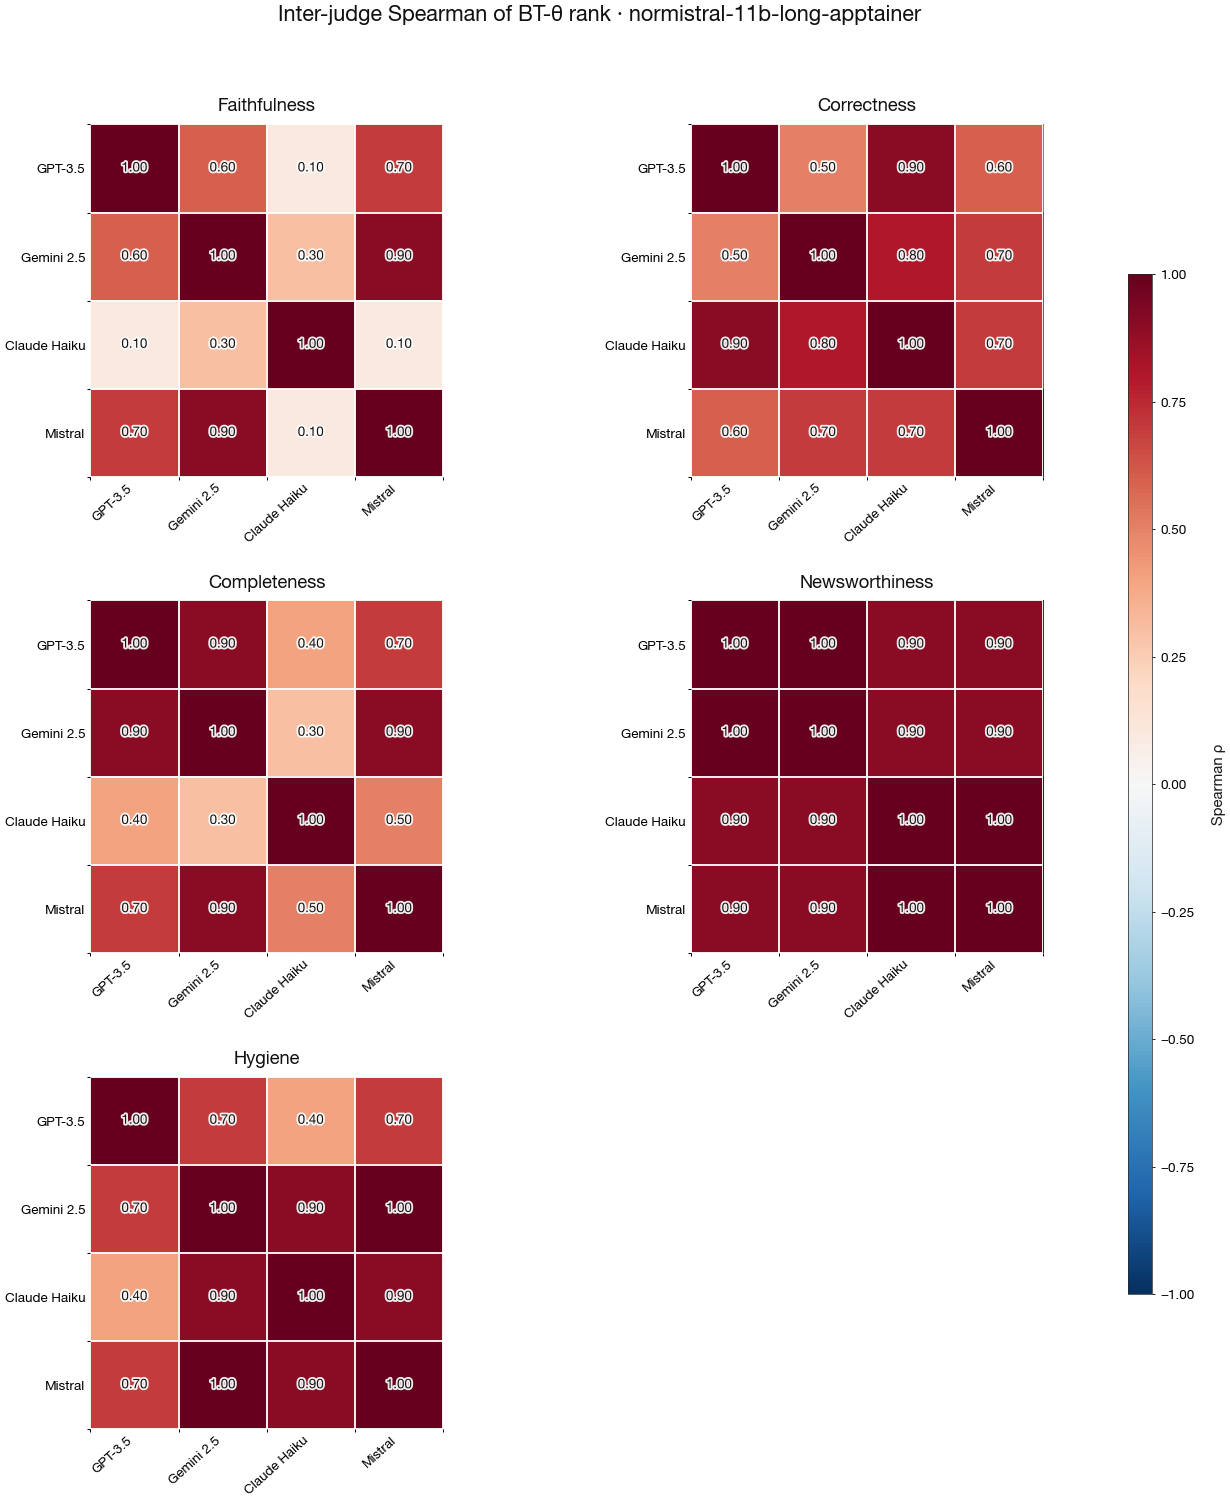

In [68]:
from pairwise_eval.config import GEVAL_EXPORT_DIRNAME, REFERENCE_SUMMARY_MODEL_ID


def _short_judge_label(judge_id: str) -> str:
    """Short labels for LLM judge ids. Defined here so this cell runs even if the helpers cell was skipped."""
    s = str(judge_id)
    if s == "gpt-3.5-turbo":
        return "GPT-3.5"
    if s.startswith("google/") and "gemini" in s:
        return "Gemini 2.5"
    if s.startswith("anthropic/"):
        return "Claude Haiku"
    if s == "mistral-medium-latest":
        return "Mistral"
    return s if len(s) <= 18 else s[:15] + "…"


# G-Eval export subfolder name (under REPO_ROOT / ".deepeval" / GEVAL_EXPORT_DIRNAME /)
BT_RANK_EXPORT_LEAF: str = "normistral-11b-long-apptainer"
# If False, only rows whose model id contains "checkpoint-"
BT_RANK_INCLUDE_REFERENCE: bool = True

_bt_path = (
    REPO_ROOT / ".deepeval" / GEVAL_EXPORT_DIRNAME / BT_RANK_EXPORT_LEAF / "tables" / "bradley_terry_long.csv"
)
if not _bt_path.is_file():
    print("Missing:", _bt_path.resolve(), "(run export for this model or set BT_RANK_EXPORT_LEAF)")
else:
    _bt_long = pd.read_csv(_bt_path)
    # judges / dimensions in file, intersect with notebook panel
    _judges_bt = [j for j in JUDGES_USED if j in set(_bt_long["judge"])]
    _dims_bt = [d for d in DIMENSIONS if d in set(_bt_long["dimension"])]
    print("BT rank agreement:", _bt_path.parent.parent.name, "| judges:", _judges_bt, "| dimensions:", _dims_bt)

    def _is_checkpoint_id(mid: str) -> bool:
        s = str(mid)
        if BT_RANK_INCLUDE_REFERENCE and s == REFERENCE_SUMMARY_MODEL_ID:
            return True
        return "checkpoint-" in s

    _panels: list[tuple[str, pd.DataFrame]] = []
    for _d in _dims_bt:
        _s = _bt_long.loc[(_bt_long["dimension"] == _d) & _bt_long["model"].map(_is_checkpoint_id)].copy()
        if _s.empty:
            print(f"  {_d}: no checkpoint rows in BT long (check filters)")
            continue
        _p = _s.pivot_table(index="model", columns="judge", values="theta", aggfunc="first")
        _p = _p.reindex(columns=_judges_bt)
        if _p.isna().any().any():
            _p = _p.dropna(axis=0, how="any")
        n_ck = len(_p)
        if n_ck < 2:
            print(f"  {_d}: need ≥2 checkpoints for Spearman, got n={n_ck}")
            continue
        # Rank 1 = best (highest θ)
        _ranks = _p.rank(ascending=False, method="average", axis=0)
        _cmr = _ranks.corr(method="spearman")
        print(
            f"  {_d}: n_checkpoints={n_ck}  Spearman of BT-based ranks (any NaN in off-diag: {_cmr.isna().any().any()})"
        )
        if _ranks.nunique().min() < 2:
            print("      (some judge has all ties → rank has no spread → some ρ undefined)")
        _panels.append((_d, _cmr))

    if not _panels:
        print("No BT-rank correlation panels to plot.")
    else:
        if len(_panels) > 6:
            print(f"WARN: {len(_panels)} dimensions — showing first 6 in the 3×2 grid only.")
            _panels = _panels[:6]
        from matplotlib import patheffects as pe

        _leaf_tag = _bt_path.parent.parent.name
        fig, axes = plt.subplots(3, 2, figsize=(11.0, 12.5))
        axes_flat = axes.ravel()
        vmin, vmax = -1.0, 1.0
        im_last = None
        for idx in range(6):
            ax = axes_flat[idx]
            if idx >= len(_panels):
                ax.axis("off")
                continue
            _d, _cmr = _panels[idx]
            labels = [_short_judge_label(c) for c in _cmr.columns]
            mat = _cmr.to_numpy(dtype=float)
            n = mat.shape[0]
            im_last = ax.imshow(
                mat,
                cmap="RdBu_r",
                vmin=vmin,
                vmax=vmax,
                aspect="equal",
                origin="upper",
                interpolation="nearest",
            )
            ax.set_xticks(np.arange(n))
            ax.set_yticks(np.arange(n))
            ax.set_xticklabels(labels, rotation=42, ha="right", fontsize=8)
            ax.set_yticklabels(labels, fontsize=8)
            ax.tick_params(length=0, pad=3)
            ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
            ax.grid(which="minor", color="white", linewidth=1.1, zorder=2)
            fs = 8 if n >= 4 else 9
            for i in range(n):
                for j in range(n):
                    val = mat[i, j]
                    if not np.isfinite(val):
                        continue
                    t = ax.text(
                        j,
                        i,
                        f"{val:.2f}",
                        ha="center",
                        va="center",
                        fontsize=fs,
                        color="#141414",
                        fontweight="700" if i == j else "500",
                        zorder=3,
                    )
                    t.set_path_effects([pe.withStroke(linewidth=2.2, foreground="white", alpha=0.92)])
            ax.set_title(_d.capitalize(), fontsize=11, fontweight="600", color="#111", pad=8)
            for spine in ax.spines.values():
                spine.set_visible(False)
        fig.suptitle(
            f"Inter-judge Spearman of BT-θ rank · {_leaf_tag}",
            fontsize=13,
            fontweight="600",
            y=1.01,
            color="#111",
        )
        fig.subplots_adjust(left=0.07, right=0.88, top=0.93, bottom=0.06, hspace=0.35, wspace=0.28)
        if im_last is not None:
            cbar_ax = fig.add_axes([0.90, 0.15, 0.018, 0.68])
            cbar = fig.colorbar(im_last, cax=cbar_ax)
            cbar.set_label("Spearman ρ", fontsize=9, labelpad=10)
            cbar.ax.tick_params(labelsize=8, length=2, width=0.5)
            cbar.outline.set_linewidth(0.45)
        if SAVE_FIGURES:
            FIGURES_DIR.mkdir(parents=True, exist_ok=True)
            _fname = f"bt_theta_rank_inter_judge_spearman_grid__{_slug_filename(_leaf_tag)}.png"
            fig.savefig(
                FIGURES_DIR / _fname,
                dpi=300,
                bbox_inches="tight",
                facecolor="white",
                edgecolor="none",
            )
        plt.show()


## 1c′. Inter-judge agreement on **checkpoint ranking from pairwise win rates**

Same layout as §1c (3×2 grid of judge×judge Spearman heatmaps), but rankings come from **`reports/results_summary.md`** in the G-Eval export: section **§1 Pairwise win rates** (markdown tables). For each dimension, each judge column is that judge’s **win rate** per checkpoint; we **rank** checkpoints by win rate (higher = better), then **Spearman** between rank columns.

Set **`WIN_RATE_SUMMARY_LEAF`** below. If you already ran §1c, it defaults to **`BT_RANK_EXPORT_LEAF`** so paths stay aligned.

**`WIN_RATE_INCLUDE_REFERENCE`:** if **`True`** (default), ranks use **every row** in the markdown win-rate table (including **`GPT4o-mini`**), matching a literal read of `results_summary.md`. If **`False`**, only `checkpoint-*` rows are ranked—Spearman between two judges can change a lot (e.g. fewer points, different ρ than a hand check that included the reference row).

Export when `SAVE_FIGURES`: **`win_rate_rank_inter_judge_spearman_grid__<leaf>.png`**.


Win-rate tables from: normistral-11b-long-apptainer | dimensions parsed: ['faithfulness', 'correctness', 'completeness', 'newsworthiness', 'hygiene']
  faithfulness: n_checkpoints=5  Spearman of win-rate ranks (any NaN in off-diag: False)
  correctness: n_checkpoints=5  Spearman of win-rate ranks (any NaN in off-diag: False)
  completeness: n_checkpoints=5  Spearman of win-rate ranks (any NaN in off-diag: False)
  newsworthiness: n_checkpoints=5  Spearman of win-rate ranks (any NaN in off-diag: False)
  hygiene: n_checkpoints=5  Spearman of win-rate ranks (any NaN in off-diag: False)


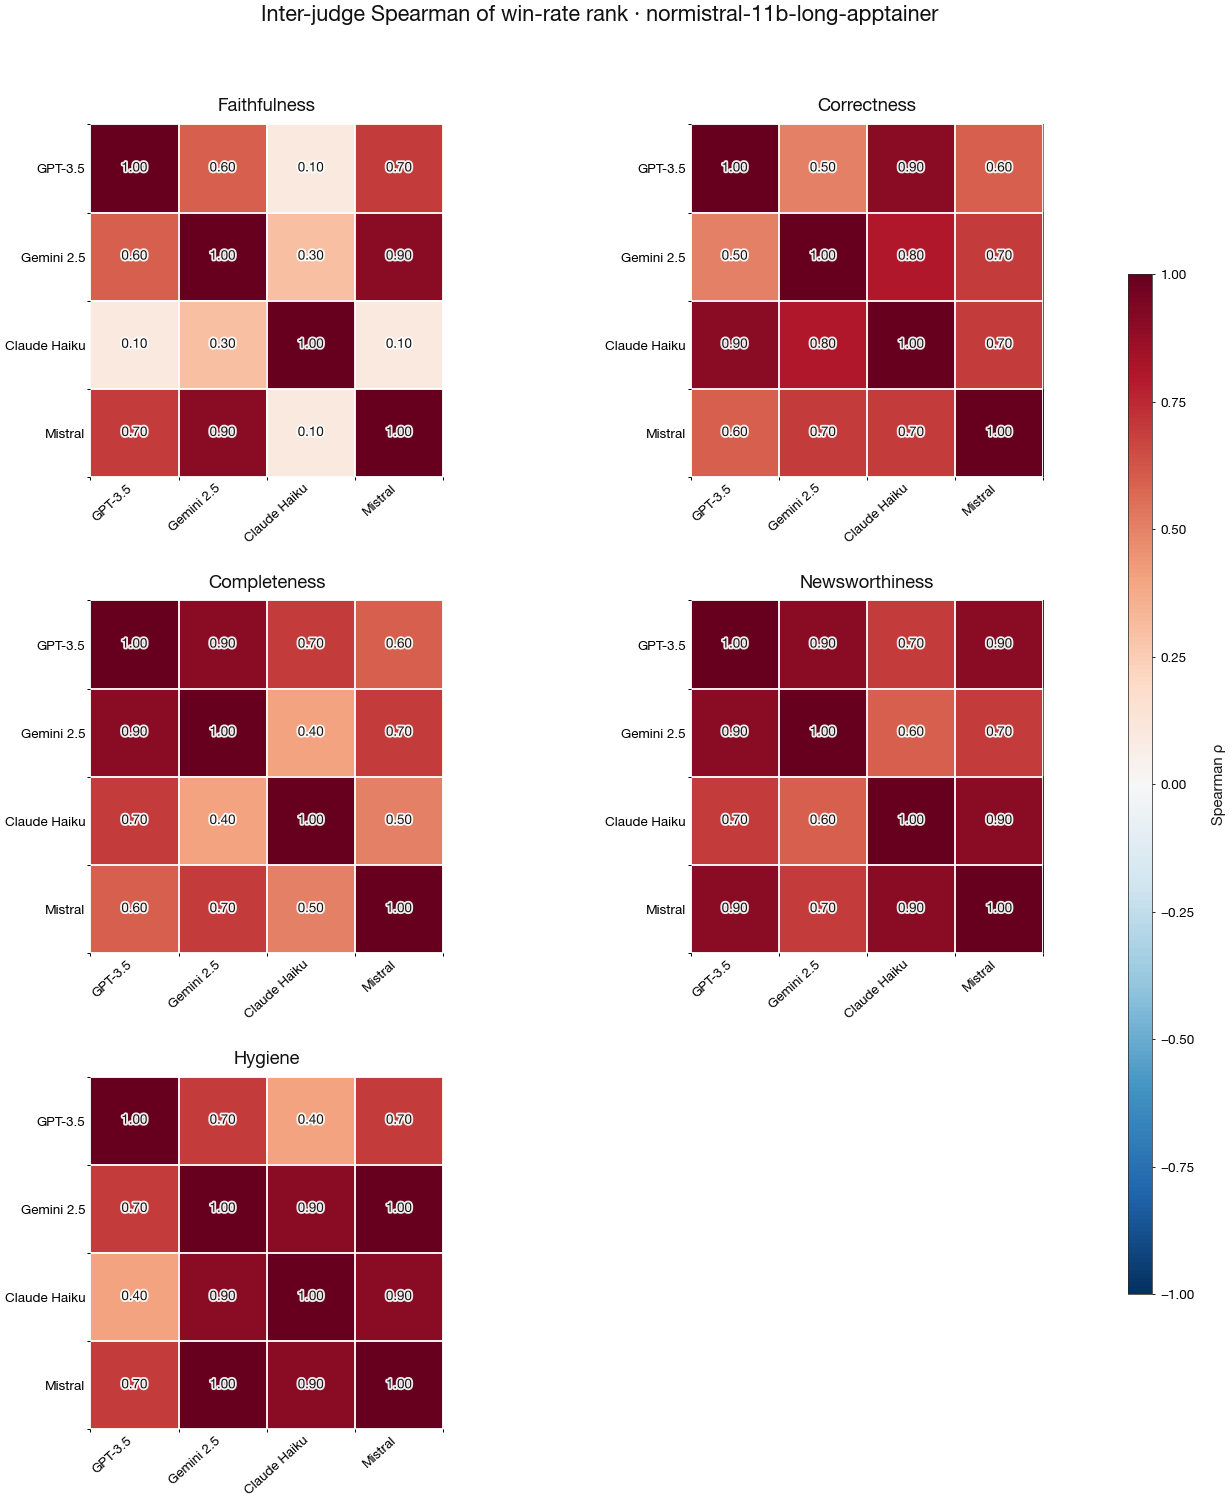

In [66]:
import re
from pathlib import Path

from pairwise_eval.config import GEVAL_EXPORT_DIRNAME, REFERENCE_SUMMARY_MODEL_ID

try:
    WIN_RATE_SUMMARY_LEAF = BT_RANK_EXPORT_LEAF
except NameError:
    WIN_RATE_SUMMARY_LEAF = "normistral-11b-long-apptainer"

WIN_RATE_INCLUDE_REFERENCE: bool = True


def _parse_win_rate_tables_from_results_summary(md_path: Path) -> dict[str, pd.DataFrame]:
    """Section '## 1. Pairwise win rates' → one DataFrame per dimension (raw markdown table)."""
    text = md_path.read_text(encoding="utf-8")
    m = re.search(r"## 1\. Pairwise win rates\s*\n(.*?)(?=\n## 2\.)", text, re.S)
    if not m:
        return {}
    sec = m.group(1)
    out: dict[str, pd.DataFrame] = {}
    for dim in DIMENSIONS:
        dim_title = dim.capitalize()
        block_m = re.search(rf"### {re.escape(dim_title)}\s*\n+(.*?)(?=\n### |\Z)", sec, re.S)
        if not block_m:
            continue
        block = block_m.group(1).strip()
        lines = [ln for ln in block.splitlines() if ln.strip().startswith("|")]
        if len(lines) < 2:
            continue
        header = [c.strip() for c in lines[0].strip().strip("|").split("|")]
        rows = []
        for ln in lines[1:]:
            if re.match(r"\|\s*---", ln):
                continue
            cells = [c.strip() for c in ln.strip().strip("|").split("|")]
            if len(cells) != len(header):
                continue
            rows.append(cells)
        if not rows:
            continue
        out[dim] = pd.DataFrame(rows, columns=header)
    return out


_wr_md = (
    REPO_ROOT / ".deepeval" / GEVAL_EXPORT_DIRNAME / WIN_RATE_SUMMARY_LEAF / "reports" / "results_summary.md"
)
if not _wr_md.is_file():
    print("Missing:", _wr_md.resolve(), "(run export or set WIN_RATE_SUMMARY_LEAF)")
else:
    _wr_tables = _parse_win_rate_tables_from_results_summary(_wr_md)
    print("Win-rate tables from:", _wr_md.parent.parent.name, "| dimensions parsed:", list(_wr_tables.keys()))

    def _is_checkpoint_id_wr(mid: str) -> bool:
        s = str(mid)
        if WIN_RATE_INCLUDE_REFERENCE and s == REFERENCE_SUMMARY_MODEL_ID:
            return True
        return "checkpoint-" in s

    _panels_wr: list[tuple[str, pd.DataFrame]] = []
    for _d in DIMENSIONS:
        if _d not in _wr_tables:
            print(f"  {_d}: no win-rate table in results_summary.md")
            continue
        df = _wr_tables[_d]
        if "model" not in df.columns:
            print(f"  {_d}: table has no 'model' column")
            continue
        rate_cols = [c for c in df.columns if str(c).endswith("_win_rate")]
        if not rate_cols:
            print(f"  {_d}: no *_win_rate columns")
            continue
        _p = df.set_index("model")[rate_cols].apply(pd.to_numeric, errors="coerce")
        _p.columns = [str(c).replace("_win_rate", "") for c in _p.columns]
        _judges_wr = [j for j in JUDGES_USED if j in _p.columns]
        _p = _p.reindex(columns=_judges_wr)
        _p = _p.loc[_p.index.map(_is_checkpoint_id_wr)]
        if _p.isna().any().any():
            _p = _p.dropna(axis=0, how="any")
        n_ck = len(_p)
        if n_ck < 2:
            print(f"  {_d}: need ≥2 checkpoints for Spearman, got n={n_ck}")
            continue
        _ranks = _p.rank(ascending=False, method="average", axis=0)
        _cmr = _ranks.corr(method="spearman")
        print(
            f"  {_d}: n_checkpoints={n_ck}  Spearman of win-rate ranks (any NaN in off-diag: {_cmr.isna().any().any()})"
        )
        if _ranks.nunique().min() < 2:
            print("      (some judge has all ties → rank has no spread → some ρ undefined)")
        _panels_wr.append((_d, _cmr))

    if not _panels_wr:
        print("No win-rate rank panels to plot.")
    else:
        if len(_panels_wr) > 6:
            print(f"WARN: {len(_panels_wr)} dimensions — showing first 6 in the 3×2 grid only.")
            _panels_wr = _panels_wr[:6]
        from matplotlib import patheffects as pe

        def _short_j_wr(judge_id: str) -> str:
            s = str(judge_id)
            if s == "gpt-3.5-turbo":
                return "GPT-3.5"
            if s.startswith("google/") and "gemini" in s:
                return "Gemini 2.5"
            if s.startswith("anthropic/"):
                return "Claude Haiku"
            if s == "mistral-medium-latest":
                return "Mistral"
            return s if len(s) <= 18 else s[:15] + "…"

        _leaf_wr = _wr_md.parent.parent.name
        fig, axes = plt.subplots(3, 2, figsize=(11.0, 12.5))
        axes_flat = axes.ravel()
        vmin, vmax = -1.0, 1.0
        im_last = None
        for idx in range(6):
            ax = axes_flat[idx]
            if idx >= len(_panels_wr):
                ax.axis("off")
                continue
            _d, _cmr = _panels_wr[idx]
            labels = [_short_j_wr(c) for c in _cmr.columns]
            mat = _cmr.to_numpy(dtype=float)
            n = mat.shape[0]
            im_last = ax.imshow(
                mat,
                cmap="RdBu_r",
                vmin=vmin,
                vmax=vmax,
                aspect="equal",
                origin="upper",
                interpolation="nearest",
            )
            ax.set_xticks(np.arange(n))
            ax.set_yticks(np.arange(n))
            ax.set_xticklabels(labels, rotation=42, ha="right", fontsize=8)
            ax.set_yticklabels(labels, fontsize=8)
            ax.tick_params(length=0, pad=3)
            ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
            ax.grid(which="minor", color="white", linewidth=1.1, zorder=2)
            fs = 8 if n >= 4 else 9
            for i in range(n):
                for j in range(n):
                    val = mat[i, j]
                    if not np.isfinite(val):
                        continue
                    t = ax.text(
                        j,
                        i,
                        f"{val:.2f}",
                        ha="center",
                        va="center",
                        fontsize=fs,
                        color="#141414",
                        fontweight="700" if i == j else "500",
                        zorder=3,
                    )
                    t.set_path_effects([pe.withStroke(linewidth=2.2, foreground="white", alpha=0.92)])
            ax.set_title(_d.capitalize(), fontsize=11, fontweight="600", color="#111", pad=8)
            for spine in ax.spines.values():
                spine.set_visible(False)
        fig.suptitle(
            f"Inter-judge Spearman of win-rate rank · {_leaf_wr}",
            fontsize=13,
            fontweight="600",
            y=1.01,
            color="#111",
        )
        fig.subplots_adjust(left=0.07, right=0.88, top=0.93, bottom=0.06, hspace=0.35, wspace=0.28)
        if im_last is not None:
            cbar_ax = fig.add_axes([0.90, 0.15, 0.018, 0.68])
            cbar = fig.colorbar(im_last, cax=cbar_ax)
            cbar.set_label("Spearman ρ", fontsize=9, labelpad=10)
            cbar.ax.tick_params(labelsize=8, length=2, width=0.5)
            cbar.outline.set_linewidth(0.45)
        if SAVE_FIGURES:
            FIGURES_DIR.mkdir(parents=True, exist_ok=True)
            _slug = re.sub(r"[^a-zA-Z0-9]+", "_", str(_leaf_wr).lower()).strip("_")[:120] or "figure"
            _fname = f"win_rate_rank_inter_judge_spearman_grid__{_slug}.png"
            fig.savefig(
                FIGURES_DIR / _fname,
                dpi=300,
                bbox_inches="tight",
                facecolor="white",
                edgecolor="none",
            )
        plt.show()


## 1c″. **Absolute** agreement on win-rate ranks (same data as 1c′)

Section **1c′** uses **Spearman** between judges: that only asks whether two judges’ **rank vectors** are **monotonically related** (same *order* up to nonlinear warping). It does **not** measure whether they assign the **same numeric ranks** to each checkpoint.

Here we summarize **consensus** among all judges on the **same** win-rate–derived ranks (**Kendall’s coefficient of concordance *W***), per dimension: *W* = 1 means every judge’s rank column is identical; *W* → 0 means rankings look unrelated as a group. We also report **mean normalized rank spread** per checkpoint (mean over models of *(max rank − min rank) / (n−1)*), where *n* is the number of ranked models—0 only if all judges tie a model at the same rank.

Uses the same **`WIN_RATE_SUMMARY_LEAF`**, **`WIN_RATE_INCLUDE_REFERENCE`**, and markdown parsing as 1c′ (re-run 1c′ first if you change those flags, or this cell re-reads `results_summary.md` with the same defaults).


In [ ]:
import re
from pathlib import Path

from pairwise_eval.config import GEVAL_EXPORT_DIRNAME, REFERENCE_SUMMARY_MODEL_ID

try:
    WIN_RATE_SUMMARY_LEAF = BT_RANK_EXPORT_LEAF
except NameError:
    WIN_RATE_SUMMARY_LEAF = "normistral-11b-long-apptainer"

try:
    _wref = WIN_RATE_INCLUDE_REFERENCE
except NameError:
    _wref = True


def _parse_win_rate_tables_wr_w(md_path: Path) -> dict[str, pd.DataFrame]:
    """Same as 1c′: Section '## 1. Pairwise win rates' → DataFrame per dimension."""
    text = md_path.read_text(encoding="utf-8")
    m = re.search(r"## 1\. Pairwise win rates\s*\n(.*?)(?=\n## 2\.)", text, re.S)
    if not m:
        return {}
    sec = m.group(1)
    out: dict[str, pd.DataFrame] = {}
    for dim in DIMENSIONS:
        dim_title = dim.capitalize()
        block_m = re.search(rf"### {re.escape(dim_title)}\s*\n+(.*?)(?=\n### |\Z)", sec, re.S)
        if not block_m:
            continue
        block = block_m.group(1).strip()
        lines = [ln for ln in block.splitlines() if ln.strip().startswith("|")]
        if len(lines) < 2:
            continue
        header = [c.strip() for c in lines[0].strip().strip("|").split("|")]
        rows = []
        for ln in lines[1:]:
            if re.match(r"\|\s*---", ln):
                continue
            cells = [c.strip() for c in ln.strip().strip("|").split("|")]
            if len(cells) != len(header):
                continue
            rows.append(cells)
        if rows:
            out[dim] = pd.DataFrame(rows, columns=header)
    return out


def _kendalls_w(rank_matrix: np.ndarray) -> float:
    """Kendall's W for n items × m raters (columns = judges). Ranks can be average ranks (ties)."""
    rank_matrix = np.asarray(rank_matrix, dtype=float)
    n, m = rank_matrix.shape
    if n < 2 or m < 2:
        return float("nan")
    R = rank_matrix.sum(axis=1)
    r_mean = R.mean()
    S = float(np.sum((R - r_mean) ** 2))
    denom = m**2 * (n**3 - n)
    if denom <= 0:
        return float("nan")
    return 12.0 * S / denom


_wr_md_w = (
    REPO_ROOT / ".deepeval" / GEVAL_EXPORT_DIRNAME / WIN_RATE_SUMMARY_LEAF / "reports" / "results_summary.md"
)
if not _wr_md_w.is_file():
    print("Missing:", _wr_md_w.resolve())
else:

    def _is_checkpoint_id_wr_w(mid: str) -> bool:
        s = str(mid)
        if _wref and s == REFERENCE_SUMMARY_MODEL_ID:
            return True
        return "checkpoint-" in s

    _tabs_w = _parse_win_rate_tables_wr_w(_wr_md_w)
    _leaf_wname = _wr_md_w.parent.parent.name
    _rows_w: list[dict] = []

    for _dim in DIMENSIONS:
        if _dim not in _tabs_w:
            continue
        df = _tabs_w[_dim]
        if "model" not in df.columns:
            continue
        rate_cols = [c for c in df.columns if str(c).endswith("_win_rate")]
        if not rate_cols:
            continue
        _p = df.set_index("model")[rate_cols].apply(pd.to_numeric, errors="coerce")
        _p.columns = [str(c).replace("_win_rate", "") for c in _p.columns]
        _judges_w = [j for j in JUDGES_USED if j in _p.columns]
        _p = _p.reindex(columns=_judges_w)
        _p = _p.loc[_p.index.map(_is_checkpoint_id_wr_w)]
        if _p.isna().any().any():
            _p = _p.dropna(axis=0, how="any")
        n_ck = len(_p)
        if n_ck < 2 or len(_judges_w) < 2:
            continue
        _ranks = _p.rank(ascending=False, method="average", axis=0)
        M = _ranks.to_numpy(dtype=float)
        W = _kendalls_w(M)
        spread = (M.max(axis=1) - M.min(axis=1)) / max(n_ck - 1, 1)
        mean_spread = float(np.mean(spread))
        _rows_w.append(
            {
                "dimension": _dim,
                "n_models": n_ck,
                "n_judges": len(_judges_w),
                "kendall_W": W,
                "mean_norm_rank_spread": mean_spread,
            }
        )

    if not _rows_w:
        print("No dimensions with enough judges/models for Kendall's W.")
    else:
        _df_w = pd.DataFrame(_rows_w).set_index("dimension")
        print(_df_w.round(4).to_string())
        fig, ax = plt.subplots(figsize=(7.2, max(3.0, 0.45 * len(_df_w))))
        y = np.arange(len(_df_w))
        ax.barh(y, _df_w["kendall_W"].to_numpy(dtype=float), color="#2c5f8a", alpha=0.88, height=0.62)
        ax.set_yticks(y)
        ax.set_yticklabels([str(x).capitalize() for x in _df_w.index], fontsize=10)
        ax.set_xlabel("Kendall's W (1 = identical rank columns)", fontsize=10)
        ax.set_title(
            f"Consensus on win-rate ranks · {_leaf_wname}",
            fontsize=12,
            fontweight="600",
            pad=10,
        )
        ax.set_xlim(0.0, 1.02)
        ax.axvline(1.0, color="#888", linewidth=0.7, linestyle="--", alpha=0.7)
        for i, (_, row) in enumerate(_df_w.iterrows()):
            ax.text(
                min(float(row["kendall_W"]) + 0.02, 0.98),
                i,
                f"spread={row['mean_norm_rank_spread']:.2f}",
                va="center",
                fontsize=8,
                color="#222",
            )
        fig.tight_layout()
        if SAVE_FIGURES:
            FIGURES_DIR.mkdir(parents=True, exist_ok=True)
            _slug = re.sub(r"[^a-zA-Z0-9]+", "_", str(_leaf_wname).lower()).strip("_")[:120] or "figure"
            fig.savefig(
                FIGURES_DIR / f"win_rate_rank_kendall_W__{_slug}.png",
                dpi=300,
                bbox_inches="tight",
                facecolor="white",
                edgecolor="none",
            )
        plt.show()



## 1c‴. **Item-level** judge agreement (percent agreement on win-rate labels)

Same win-rate tables as **1c′** (per checkpoint / model row, each judge has a numeric **win rate**). We **bin** each judge’s rate into **`WIN_RATE_AGREEMENT_BINS`** ordinal labels on **[0, 1]** (equal-width bins). This is **not** rank-based: two judges “agree” on an item if their **labels** are equal.

**Percent agreement (strict, all judges):**

\[
100 \times \frac{\text{\# items where every judge has the same label}}{\text{\# items}}
\]

We also print **mean pairwise percent agreement**: for each unordered judge pair, the fraction of items where the two labels match, averaged over pairs.


In [ ]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pairwise_eval.config import GEVAL_EXPORT_DIRNAME, REFERENCE_SUMMARY_MODEL_ID

try:
    WIN_RATE_SUMMARY_LEAF = BT_RANK_EXPORT_LEAF
except NameError:
    WIN_RATE_SUMMARY_LEAF = "normistral-11b-long-apptainer"

try:
    _wref_pa = WIN_RATE_INCLUDE_REFERENCE
except NameError:
    _wref_pa = True

WIN_RATE_AGREEMENT_BINS: int = 5


def _rate_to_label(x: float, n_bins: int) -> int:
    x = float(np.clip(x, 0.0, 1.0))
    b = int(np.floor(x * n_bins))
    return min(b, n_bins - 1)


def _parse_win_rate_tables_pa(md_path: Path) -> dict[str, pd.DataFrame]:
    text = md_path.read_text(encoding="utf-8")
    m = re.search(r"## 1\. Pairwise win rates\s*\n(.*?)(?=\n## 2\.)", text, re.S)
    if not m:
        return {}
    sec = m.group(1)
    out: dict[str, pd.DataFrame] = {}
    for dim in DIMENSIONS:
        dim_title = dim.capitalize()
        block_m = re.search(rf"### {re.escape(dim_title)}\s*\n+(.*?)(?=\n### |\Z)", sec, re.S)
        if not block_m:
            continue
        block = block_m.group(1).strip()
        lines = [ln for ln in block.splitlines() if ln.strip().startswith("|")]
        if len(lines) < 2:
            continue
        header = [c.strip() for c in lines[0].strip().strip("|").split("|")]
        rows = []
        for ln in lines[1:]:
            if re.match(r"\|\s*---", ln):
                continue
            cells = [c.strip() for c in ln.strip().strip("|").split("|")]
            if len(cells) != len(header):
                continue
            rows.append(cells)
        if rows:
            out[dim] = pd.DataFrame(rows, columns=header)
    return out


_wr_md_pa = (
    REPO_ROOT / ".deepeval" / GEVAL_EXPORT_DIRNAME / WIN_RATE_SUMMARY_LEAF / "reports" / "results_summary.md"
)
if not _wr_md_pa.is_file():
    print("Missing:", _wr_md_pa.resolve())
else:

    def _is_checkpoint_id_pa(mid: str) -> bool:
        s = str(mid)
        if _wref_pa and s == REFERENCE_SUMMARY_MODEL_ID:
            return True
        return "checkpoint-" in s

    _tabs_pa = _parse_win_rate_tables_pa(_wr_md_pa)
    _leaf_pa = _wr_md_pa.parent.parent.name
    B = int(WIN_RATE_AGREEMENT_BINS)
    if B < 2:
        raise ValueError("WIN_RATE_AGREEMENT_BINS must be >= 2")

    rows_out: list[dict] = []

    for _dim in DIMENSIONS:
        if _dim not in _tabs_pa:
            continue
        df = _tabs_pa[_dim]
        if "model" not in df.columns:
            continue
        rate_cols = [c for c in df.columns if str(c).endswith("_win_rate")]
        if not rate_cols:
            continue
        _p = df.set_index("model")[rate_cols].apply(pd.to_numeric, errors="coerce")
        _p.columns = [str(c).replace("_win_rate", "") for c in _p.columns]
        _judges_pa = [j for j in JUDGES_USED if j in _p.columns]
        _p = _p.reindex(columns=_judges_pa)
        _p = _p.loc[_p.index.map(_is_checkpoint_id_pa)]
        if _p.isna().any().any():
            _p = _p.dropna(axis=0, how="any")
        n_items = len(_p)
        if n_items < 1 or len(_judges_pa) < 2:
            continue

        L = _p.map(lambda v: _rate_to_label(v, B)).astype(int)
        n_all_same = int((L.nunique(axis=1) == 1).sum())
        pct_strict = 100.0 * n_all_same / n_items

        pairs = []
        for i in range(len(_judges_pa)):
            for j in range(i + 1, len(_judges_pa)):
                a, b = _judges_pa[i], _judges_pa[j]
                pairs.append(float((L[a] == L[b]).mean() * 100.0))
        mean_pair_pct = float(np.mean(pairs)) if pairs else float("nan")

        rows_out.append(
            {
                "dimension": _dim,
                "n_items": n_items,
                "n_judges": len(_judges_pa),
                "bins": B,
                "n_items_all_judges_same_label": n_all_same,
                "pct_agreement_strict": pct_strict,
                "mean_pairwise_pct_agreement": mean_pair_pct,
            }
        )

    if not rows_out:
        print("No dimensions with enough data for percent agreement.")
    else:
        _df_pa = pd.DataFrame(rows_out).set_index("dimension")
        print(_df_pa.round(2).to_string())
        fig, ax = plt.subplots(figsize=(7.2, max(3.0, 0.45 * len(_df_pa))))
        y = np.arange(len(_df_pa))
        vals = _df_pa["pct_agreement_strict"].to_numpy(dtype=float)
        ax.barh(y, vals, color="#1a6b4a", alpha=0.88, height=0.62)
        ax.set_yticks(y)
        ax.set_yticklabels([str(x).capitalize() for x in _df_pa.index], fontsize=10)
        ax.set_xlabel(
            f"% items with identical label across all judges ({B} equal-width bins on [0,1])",
            fontsize=9,
        )
        ax.set_title(
            f"Item-level percent agreement (win rates) · {_leaf_pa}",
            fontsize=12,
            fontweight="600",
            pad=10,
        )
        ax.set_xlim(0.0, 102.0)
        for i, (_, row) in enumerate(_df_pa.iterrows()):
            ax.text(
                min(float(row["pct_agreement_strict"]) + 1.5, 96.0),
                i,
                f"pair≈{row['mean_pairwise_pct_agreement']:.0f}%",
                va="center",
                fontsize=8,
                color="#222",
            )
        fig.tight_layout()
        if SAVE_FIGURES:
            FIGURES_DIR.mkdir(parents=True, exist_ok=True)
            _slug = re.sub(r"[^a-zA-Z0-9]+", "_", str(_leaf_pa).lower()).strip("_")[:120] or "figure"
            fig.savefig(
                FIGURES_DIR / f"win_rate_item_pct_agreement__{_slug}.png",
                dpi=300,
                bbox_inches="tight",
                facecolor="white",
                edgecolor="none",
            )
        plt.show()



## 1d. **Bradley–Terry θ** vs **per-judge win rate** (across checkpoints)

For every G-Eval **export** leaf under `.deepeval/<GEVAL_EXPORT_DIRNAME>/` that has both **`tables/bradley_terry_long.csv`** (θ per dimension × judge × model) and **`reports/results_summary.md`** (Section 1 pairwise win-rate tables): for each **(dimension, judge)**, take the **same `model` rows** in both sources and compute **Spearman** ρ between **θ** and that judge’s **win rate**. Heatmap layout in each panel: **rows = dimensions**, **columns = judges**; one cell = correlation across **all models in the join** (including `GPT4o-mini` when present in both tables).

All such leaves (alphabetically sorted, **up to 10**) are shown in **one figure** as a **5×2** grid of heatmaps—one subplot per export folder (e.g. `gemma-2-9b`, `normistral-11b-long-apptainer`). If there are fewer than 10 export leaves with both files, remaining panels are left blank; if there are more than 10, only the first 10 are plotted and a short warning is printed.

Extreme θ values (e.g. separation under one judge) can still leave Spearman well-defined because it uses ranks.


In [ ]:
import re
from pathlib import Path

from pairwise_eval.config import GEVAL_EXPORT_DIRNAME, REPO_ROOT


def _parse_win_rate_tables_bt_wr(md_path: Path) -> dict[str, pd.DataFrame]:
    """Section '## 1. Pairwise win rates' in results_summary.md → DataFrame per dimension."""
    text = md_path.read_text(encoding="utf-8")
    m = re.search(r"## 1\. Pairwise win rates\s*\n(.*?)(?=\n## 2\.)", text, re.S)
    if not m:
        return {}
    sec = m.group(1)
    out: dict[str, pd.DataFrame] = {}
    for dim in DIMENSIONS:
        dim_title = dim.capitalize()
        block_m = re.search(rf"### {re.escape(dim_title)}\s*\n+(.*?)(?=\n### |\Z)", sec, re.S)
        if not block_m:
            continue
        block = block_m.group(1).strip()
        lines = [ln for ln in block.splitlines() if ln.strip().startswith("|")]
        if len(lines) < 2:
            continue
        header = [c.strip() for c in lines[0].strip().strip("|").split("|")]
        rows = []
        for ln in lines[1:]:
            if re.match(r"\|\s*---", ln):
                continue
            cells = [c.strip() for c in ln.strip().strip("|").split("|")]
            if len(cells) != len(header):
                continue
            rows.append(cells)
        if rows:
            out[dim] = pd.DataFrame(rows, columns=header)
    return out


def _sjl_bt_wr(judge_id: str) -> str:
    s = str(judge_id)
    if s == "gpt-3.5-turbo":
        return "GPT-3.5"
    if s.startswith("google/") and "gemini" in s:
        return "Gemini 2.5"
    if s.startswith("anthropic/"):
        return "Claude Haiku"
    if s == "mistral-medium-latest":
        return "Mistral"
    return s if len(s) <= 18 else s[:15] + "…"


def _bt_wr_pivot_one_leaf(
    leaf_root: Path,
    *,
    judges: tuple[str, ...],
) -> pd.DataFrame | None:
    """Return pivot (rows=dimension, cols=judge) of Spearman ρ between θ and win rate, or None if missing."""
    _bt_csv = leaf_root / "tables" / "bradley_terry_long.csv"
    _wr_md = leaf_root / "reports" / "results_summary.md"
    if not _bt_csv.is_file() or not _wr_md.is_file():
        return None
    _bt_all = pd.read_csv(_bt_csv)
    _wr_tabs = _parse_win_rate_tables_bt_wr(_wr_md)
    _jc = [j for j in judges if j in set(_bt_all["judge"])]
    if not _jc:
        return None
    _rho: dict[tuple[str, str], float] = {}
    for _dim in DIMENSIONS:
        if _dim not in _wr_tabs:
            continue
        _wdf = _wr_tabs[_dim]
        if "model" not in _wdf.columns:
            continue
        for _j in _jc:
            _wcol = f"{_j}_win_rate"
            if _wcol not in _wdf.columns:
                continue
            _bt_sub = _bt_all.loc[
                (_bt_all["dimension"] == _dim) & (_bt_all["judge"] == _j), ["model", "theta"]
            ].copy()
            _wr_sub = _wdf[["model", _wcol]].copy()
            _wr_sub[_wcol] = pd.to_numeric(_wr_sub[_wcol], errors="coerce")
            _m = _bt_sub.merge(_wr_sub, on="model", how="inner").dropna(subset=["theta", _wcol])
            if len(_m) < 3:
                _rho[(_dim, _j)] = float("nan")
            else:
                _rho[(_dim, _j)] = float(_m["theta"].corr(_m[_wcol], method="spearman"))
    pivot = pd.DataFrame(index=list(DIMENSIONS), columns=_jc, dtype=float)
    for (_dim, _j), v in _rho.items():
        if _dim in pivot.index and _j in pivot.columns:
            pivot.loc[_dim, _j] = v
    return pivot


_geval_export_root = REPO_ROOT / ".deepeval" / GEVAL_EXPORT_DIRNAME
_leaf_dirs: list[Path] = []
if _geval_export_root.is_dir():
    for _p in sorted(_geval_export_root.iterdir()):
        if not _p.is_dir() or _p.name == "images":
            continue
        if (_p / "tables" / "bradley_terry_long.csv").is_file() and (_p / "reports" / "results_summary.md").is_file():
            _leaf_dirs.append(_p)

if len(_leaf_dirs) > 10:
    print("WARN: more than 10 export leaves — showing first 10 only (alphabetical).")

_panels_bt_wr: list[tuple[str, pd.DataFrame | None]] = []
for _p in _leaf_dirs[:10]:
    mat = _bt_wr_pivot_one_leaf(_p, judges=JUDGES_USED)
    _panels_bt_wr.append((_p.name, mat))

if len(_leaf_dirs) < 10:
    while len(_panels_bt_wr) < 10:
        _panels_bt_wr.append(("", None))

if not any(m is not None for _, m in _panels_bt_wr):
    print("No export folders with both bradley_terry_long.csv and results_summary.md under", _geval_export_root.resolve())
else:
    from matplotlib import patheffects as pe

    fig, axes = plt.subplots(5, 2, figsize=(13.5, 22.0))
    axes_flat = axes.ravel()
    vmin, vmax = -1.0, 1.0
    im_last = None
    for idx in range(10):
        ax = axes_flat[idx]
        _name, _piv = _panels_bt_wr[idx]
        if not _name or _piv is None:
            ax.axis("off")
            continue
        _mat = _piv.to_numpy(dtype=float)
        n_r, n_c = _mat.shape
        im_last = ax.imshow(
            _mat,
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
            aspect="auto",
            origin="upper",
            interpolation="nearest",
        )
        ax.set_xticks(np.arange(n_c))
        ax.set_yticks(np.arange(n_r))
        ax.set_xticklabels([_sjl_bt_wr(j) for j in _piv.columns], rotation=45, ha="right", fontsize=7)
        ax.set_yticklabels([str(x).capitalize() for x in _piv.index], fontsize=7)
        ax.tick_params(length=0, pad=2)
        ax.set_xticks(np.arange(-0.5, n_c, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, n_r, 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=0.85, zorder=2)
        for i in range(n_r):
            for j in range(n_c):
                v = _mat[i, j]
                if not np.isfinite(v):
                    txt = "—"
                else:
                    txt = f"{v:.2f}"
                t = ax.text(
                    j,
                    i,
                    txt,
                    ha="center",
                    va="center",
                    fontsize=6,
                    color="#141414",
                    fontweight="600",
                    zorder=3,
                )
                t.set_path_effects([pe.withStroke(linewidth=1.8, foreground="white", alpha=0.92)])
        ax.set_title(_name, fontsize=9, fontweight="600", pad=5)
        for spine in ax.spines.values():
            spine.set_visible(False)

    fig.suptitle(
        "Spearman ρ: BT θ vs win rate (across models) · up to 10 G-Eval export leaves",
        fontsize=12.5,
        fontweight="600",
        y=0.995,
    )
    fig.subplots_adjust(left=0.06, right=0.91, top=0.96, bottom=0.04, hspace=0.42, wspace=0.28)
    if im_last is not None:
        cbar_ax = fig.add_axes([0.93, 0.15, 0.014, 0.55])
        cbar = fig.colorbar(im_last, cax=cbar_ax)
        cbar.set_label("Spearman ρ", fontsize=9, labelpad=8)
        cbar.ax.tick_params(labelsize=8)
    if SAVE_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            FIGURES_DIR / "bt_theta_vs_win_rate_spearman__all_export_leaves_5x2.png",
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
    plt.show()



## 2. Inter-dimension correlation (within each judge)

**Spearman** ρ only. Same comparison must exist for **every** dimension in the tuple (complete cases only).

gpt-3.5-turbo: n = 100 comparisons with all dimensions
google/gemini-2.5-flash-preview-05-20: n = 100 comparisons with all dimensions
anthropic/claude-3-5-haiku-20241022: n = 100 comparisons with all dimensions
mistral-medium-latest: n = 100 comparisons with all dimensions


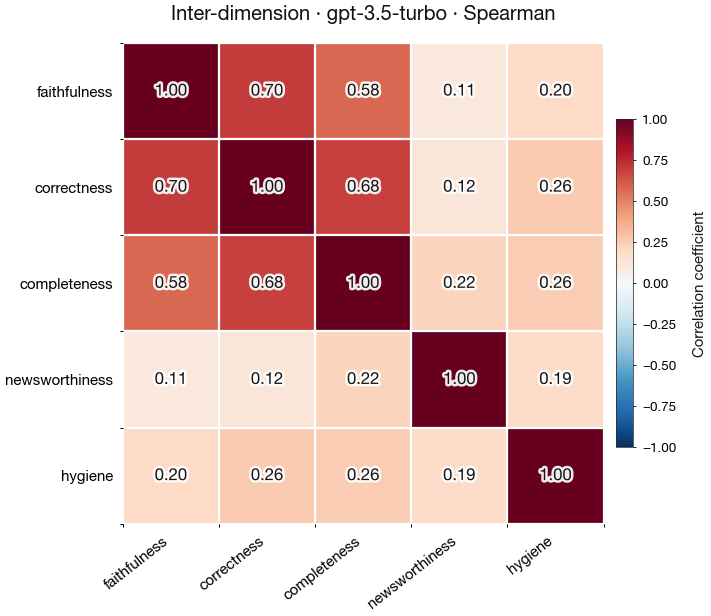

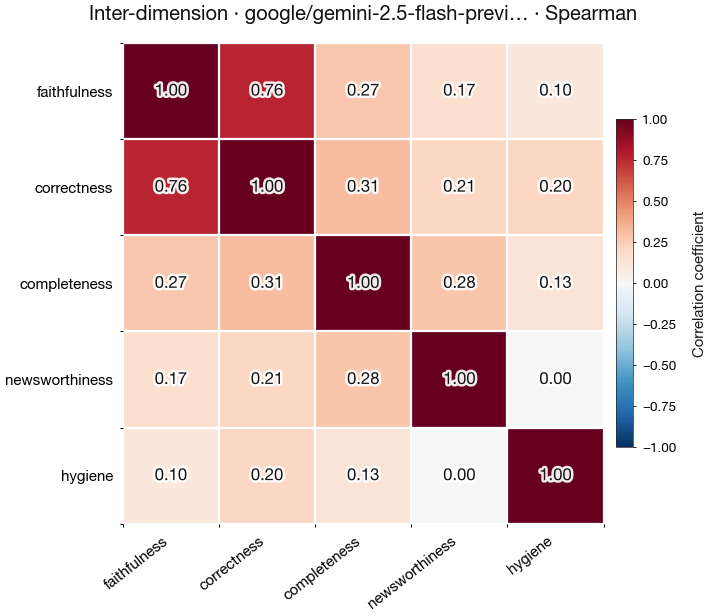

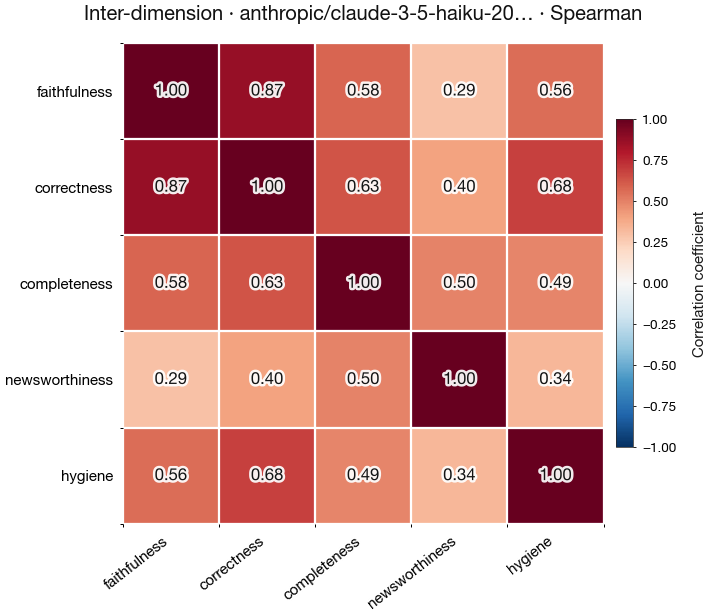

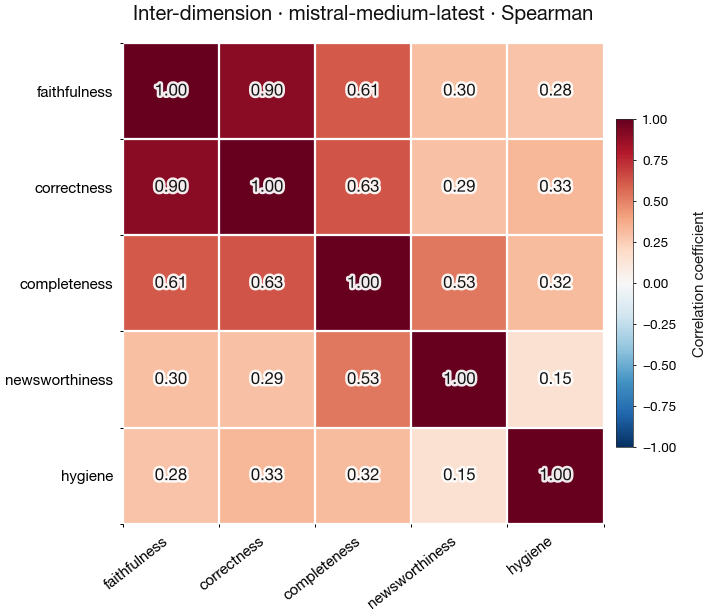

In [34]:
inter_dimension_results: dict[str, pd.DataFrame] = {}

for judge in JUDGES_USED:
    sub = long_df.loc[long_df["judge"] == judge].copy()
    if sub.empty:
        print(f"{judge}: no rows")
        continue
    sub["cmp"] = sub.apply(comparison_key_inter_dimension, axis=1)
    wide = sub.pivot_table(index="cmp", columns="dimension", values="score", aggfunc="first")
    wide = wide.reindex(columns=list(DIMENSIONS))
    wide = wide.dropna(axis=0, how="any")
    n = len(wide)
    print(f"{judge}: n = {n} comparisons with all dimensions")
    if n < 3:
        print("  skip correlation")
        continue
    inter_dimension_results[judge] = corr_matrix_for_subset(wide, "spearman")

for judge, cm in inter_dimension_results.items():
    plot_correlation_matrix(
        cm,
        f"Inter-dimension · {_short_label(judge)} · Spearman",
    )



## 3. Optional: single table — mean inter-judge Spearman by dimension

Off-diagonal entries only (unique judge pairs), same matrices as §1.

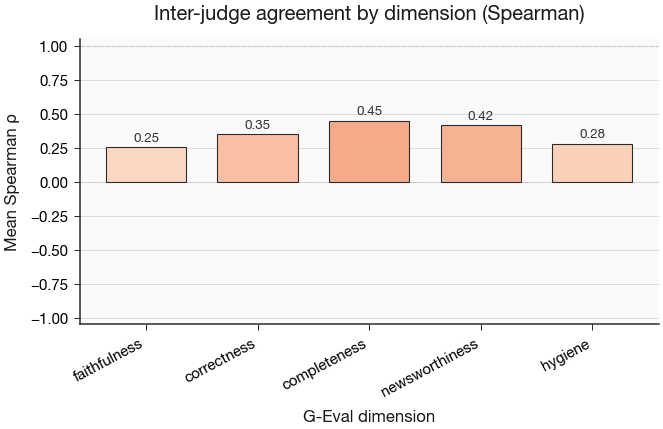

In [45]:
summary_rows = []
for dim, cm in inter_judge_results.items():
    judges_l = list(cm.columns)
    pairs = []
    for i, a in enumerate(judges_l):
        for b in judges_l[i + 1 :]:
            pairs.append(cm.loc[a, b])
    if pairs:
        summary_rows.append(
            {"dimension": dim, "mean_spearman_judge_pairs": float(np.mean(pairs)), "n_pairs": len(pairs)}
        )

summary_df = pd.DataFrame(summary_rows) if summary_rows else pd.DataFrame()

if not summary_df.empty and "mean_spearman_judge_pairs" in summary_df.columns:
    dims = summary_df["dimension"].astype(str).tolist()
    vals = summary_df["mean_spearman_judge_pairs"].to_numpy(dtype=float)
    n_b = len(dims)
    fig_w = min(7.8, max(5.2, 0.55 * n_b + 3.0))
    fig, ax = plt.subplots(figsize=(fig_w, 3.8))
    x = np.arange(n_b)
    norm01 = (np.clip(vals, -1.0, 1.0) + 1.0) / 2.0
    colors = plt.cm.RdBu_r(0.08 + 0.84 * norm01)
    bars = ax.bar(
        x,
        vals,
        color=colors,
        edgecolor="#2a2a2a",
        linewidth=0.65,
        width=0.72,
        zorder=2,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(dims, rotation=28, ha="right", fontsize=9)
    ax.set_ylabel("Mean Spearman ρ", fontsize=10, labelpad=6)
    ax.set_xlabel("G-Eval dimension", fontsize=10, labelpad=6)
    ax.set_title(
        "Inter-judge agreement by dimension (Spearman)",
        fontsize=12,
        fontweight="600",
        pad=12,
    )
    lo = float(np.nanmin(vals)) if np.any(np.isfinite(vals)) else -1.0
    hi = float(np.nanmax(vals)) if np.any(np.isfinite(vals)) else 1.0
    ax.set_ylim(min(-1.05, lo - 0.1), max(1.05, hi + 0.12))
    ax.axhline(1.0, color="#cccccc", linewidth=0.7, linestyle="--", zorder=1)
    ax.axhline(0.0, color="#bbbbbb", linewidth=0.55, linestyle=":", zorder=1)
    ax.yaxis.grid(True, linestyle="-", linewidth=0.45, alpha=0.35, color="#888888")
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for b, v in zip(bars, vals):
        if np.isfinite(v):
            ax.text(
                b.get_x() + b.get_width() / 2.0,
                b.get_height() + 0.02 * np.sign(v) if v != 0 else 0.02,
                f"{v:.2f}",
                ha="center",
                va="bottom" if v >= 0 else "top",
                fontsize=8,
                color="#333333",
            )
    fig.tight_layout()
    if SAVE_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            FIGURES_DIR / "mean_inter_judge_spearman_by_dimension.png",
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
    plt.show()

## Win-rate profile across **checkpoints** (multi-dimension lines)

For one G-Eval **export** leaf (summarization **model** *X*), read **`reports/results_summary.md`** (Section 1 pairwise win-rate tables). **x-axis:** checkpoint rows, ordered by step in the id. **y-axis:** win rate; **one coloured line per dimension**.

**`WIN_RATE_PROFILE_MODE`** (default **`"facet_judges"`**): **`"facet_judges"`** draws a **small grid of panels—one panel per judge**, same dimension colours in each panel (shared axes, compact tick labels). **`"mean"`** averages over **`JUDGES_USED`**. **`"single_judge"`** uses **`WIN_RATE_PROFILE_JUDGE`** only.

**`WIN_RATE_PROFILE_CHECKPOINTS_ONLY`:** if `True`, only `checkpoint-*` rows (no `GPT4o-mini` on the axis).


In [ ]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from pairwise_eval.config import GEVAL_EXPORT_DIRNAME, REFERENCE_SUMMARY_MODEL_ID

try:
    WIN_RATE_PROFILE_LEAF = WIN_RATE_SUMMARY_LEAF
except NameError:
    try:
        WIN_RATE_PROFILE_LEAF = BT_RANK_EXPORT_LEAF
    except NameError:
        WIN_RATE_PROFILE_LEAF = "gemma-2-9b"

WIN_RATE_PROFILE_MODE: str = "facet_judges"
WIN_RATE_PROFILE_JUDGE: str | None = None
WIN_RATE_PROFILE_CHECKPOINTS_ONLY: bool = True


def _parse_win_rate_section_profile(md_path: Path) -> dict[str, pd.DataFrame]:
    text = md_path.read_text(encoding="utf-8")
    m = re.search(r"## 1\. Pairwise win rates\s*\n(.*?)(?=\n## 2\.)", text, re.S)
    if not m:
        return {}
    sec = m.group(1)
    out: dict[str, pd.DataFrame] = {}
    for dim in DIMENSIONS:
        dim_title = dim.capitalize()
        block_m = re.search(rf"### {re.escape(dim_title)}\s*\n+(.*?)(?=\n### |\Z)", sec, re.S)
        if not block_m:
            continue
        block = block_m.group(1).strip()
        lines = [ln for ln in block.splitlines() if ln.strip().startswith("|")]
        if len(lines) < 2:
            continue
        header = [c.strip() for c in lines[0].strip().strip("|").split("|")]
        rows = []
        for ln in lines[1:]:
            if re.match(r"\|\s*---", ln):
                continue
            cells = [c.strip() for c in ln.strip().strip("|").split("|")]
            if len(cells) != len(header):
                continue
            rows.append(cells)
        if rows:
            out[dim] = pd.DataFrame(rows, columns=header)
    return out


def _checkpoint_step(model_id: str) -> int | None:
    s = str(model_id)
    mm = re.match(r"checkpoint-(\d+)-", s)
    return int(mm.group(1)) if mm else None


def _short_ckpt_tick(model_id: str, max_len: int = 28) -> str:
    s = str(model_id)
    if s == REFERENCE_SUMMARY_MODEL_ID:
        return s
    m = re.match(r"(checkpoint-\d+)", s)
    if m:
        return m.group(1)
    return s if len(s) <= max_len else s[: max_len - 1] + "…"


def _short_j_prof(judge_id: str) -> str:
    s = str(judge_id)
    if s == "gpt-3.5-turbo":
        return "GPT-3.5"
    if s.startswith("google/") and "gemini" in s:
        return "Gemini 2.5"
    if s.startswith("anthropic/"):
        return "Claude Haiku"
    if s == "mistral-medium-latest":
        return "Mistral"
    return s if len(s) <= 16 else s[:13] + "…"


_md_prof = (
    REPO_ROOT / ".deepeval" / GEVAL_EXPORT_DIRNAME / WIN_RATE_PROFILE_LEAF / "reports" / "results_summary.md"
)
if not _md_prof.is_file():
    print("Missing:", _md_prof.resolve())
else:
    _tabs_prof = _parse_win_rate_section_profile(_md_prof)
    _sets_m: list[set[str]] = []
    for _d in DIMENSIONS:
        if _d in _tabs_prof and "model" in _tabs_prof[_d].columns:
            _sets_m.append(set(_tabs_prof[_d]["model"].astype(str)))
    _models_common: set[str] = set.intersection(*_sets_m) if _sets_m else set()

    def _keep_row(mid: str) -> bool:
        s = str(mid)
        if WIN_RATE_PROFILE_CHECKPOINTS_ONLY:
            return "checkpoint-" in s
        if s == REFERENCE_SUMMARY_MODEL_ID:
            return True
        return "checkpoint-" in s

    _candidates = sorted([m for m in _models_common if _keep_row(m)], key=lambda x: (_checkpoint_step(x) is None, _checkpoint_step(x) or 0, x))
    if not _candidates:
        print("No checkpoint rows to plot (check WIN_RATE_PROFILE_CHECKPOINTS_ONLY / tables).")
    else:
        _mode = str(WIN_RATE_PROFILE_MODE).strip().lower().replace("-", "_")
        _x = np.arange(len(_candidates))
        _xtick_lbl = [_short_ckpt_tick(m) for m in _candidates]
        _dims_ok = [d for d in DIMENSIONS if d in _tabs_prof and "model" in _tabs_prof[d].columns]
        _cmap = plt.cm.tab10(np.linspace(0, 0.9, max(len(_dims_ok), 2)))

        def _wr_frame_for_dim(_dim: str) -> pd.DataFrame | None:
            df = _tabs_prof[_dim]
            rate_cols = [c for c in df.columns if str(c).endswith("_win_rate")]
            if not rate_cols:
                return None
            wr = df.set_index("model")[rate_cols].apply(pd.to_numeric, errors="coerce")
            wr.columns = [str(c).replace("_win_rate", "") for c in wr.columns]
            return wr

        if _mode == "single_judge":
            if not WIN_RATE_PROFILE_JUDGE:
                raise ValueError('WIN_RATE_PROFILE_MODE="single_judge" requires WIN_RATE_PROFILE_JUDGE to be set')
            fig, ax = plt.subplots(figsize=(max(10.0, 0.42 * len(_candidates)), 5.8))
            for _i, _dim in enumerate(_dims_ok):
                wr = _wr_frame_for_dim(_dim)
                if wr is None:
                    continue
                j = str(WIN_RATE_PROFILE_JUDGE)
                if j not in wr.columns:
                    print(f"  {_dim}: judge {j!r} not in table")
                    continue
                y = wr.reindex(_candidates)[j].to_numpy(dtype=float)
                ax.plot(_x, y, color=_cmap[_i % len(_cmap)], marker="o", ms=4, lw=2.0, label=_dim.capitalize(), alpha=0.92)
            ax.set_xticks(_x)
            ax.set_xticklabels(_xtick_lbl, rotation=48, ha="right", fontsize=8)
            ax.set_ylabel("Win rate", fontsize=11)
            ax.set_xlabel("Checkpoint (model id)", fontsize=11, labelpad=6)
            ax.set_ylim(-0.02, 1.02)
            ax.axhline(0.5, color="#bbb", ls="--", lw=0.9, zorder=0)
            ax.legend(title="Dimension", loc="upper right", fontsize=9, title_fontsize=9, framealpha=0.92)
            ax.set_title(
                f"Win rates vs checkpoint · {WIN_RATE_PROFILE_LEAF} · judge = {WIN_RATE_PROFILE_JUDGE}",
                fontsize=12,
                fontweight="600",
                pad=10,
            )
            ax.grid(True, axis="y", alpha=0.35)
            _suffix = "single"
        elif _mode == "mean":
            fig, ax = plt.subplots(figsize=(max(10.0, 0.42 * len(_candidates)), 5.8))
            for _i, _dim in enumerate(_dims_ok):
                wr = _wr_frame_for_dim(_dim)
                if wr is None:
                    continue
                _jc = [j for j in JUDGES_USED if j in wr.columns]
                if not _jc:
                    continue
                y = wr.reindex(_candidates)[_jc].mean(axis=1).to_numpy(dtype=float)
                ax.plot(_x, y, color=_cmap[_i % len(_cmap)], marker="o", ms=4, lw=2.0, label=_dim.capitalize(), alpha=0.92)
            ax.set_xticks(_x)
            ax.set_xticklabels(_xtick_lbl, rotation=48, ha="right", fontsize=8)
            ax.set_ylabel("Win rate (mean over judges)", fontsize=11)
            ax.set_xlabel("Checkpoint (model id)", fontsize=11, labelpad=6)
            ax.set_ylim(-0.02, 1.02)
            ax.axhline(0.5, color="#bbb", ls="--", lw=0.9, zorder=0)
            ax.legend(title="Dimension", loc="upper right", fontsize=9, title_fontsize=9, framealpha=0.92)
            ax.set_title(
                f"Win rates vs checkpoint · {WIN_RATE_PROFILE_LEAF} · mean over judges",
                fontsize=12,
                fontweight="600",
                pad=10,
            )
            ax.grid(True, axis="y", alpha=0.35)
            _suffix = "mean"
        elif _mode in ("facet_judges", "faceted_judges", "judges"):
            _jc_all = [j for j in JUDGES_USED]
            _first_wr = _wr_frame_for_dim(_dims_ok[0]) if _dims_ok else None
            if _first_wr is None:
                print("No dimension tables with win rates.")
                raise SystemExit
            _jc_all = [j for j in _jc_all if j in _first_wr.columns]
            if len(_jc_all) < 1:
                print("No judge columns in common with JUDGES_USED.")
                raise SystemExit
            n_j = len(_jc_all)
            ncols = int(np.ceil(np.sqrt(n_j)))
            nrows = int(np.ceil(n_j / ncols))
            fig_w = max(10.5, 0.38 * len(_candidates) * ncols)
            fig_h = max(3.2, 2.85 * nrows)
            fig, axes = plt.subplots(
                nrows,
                ncols,
                figsize=(fig_w, fig_h),
                sharex=True,
                sharey=True,
                squeeze=False,
            )
            axes_flat = np.atleast_1d(axes).ravel()
            for ax_j in axes_flat[n_j:]:
                ax_j.axis("off")
            for j_idx, judge in enumerate(_jc_all):
                ax = axes_flat[j_idx]
                for _i, _dim in enumerate(_dims_ok):
                    wr = _wr_frame_for_dim(_dim)
                    if wr is None or judge not in wr.columns:
                        continue
                    y = wr.reindex(_candidates)[judge].to_numpy(dtype=float)
                    ax.plot(
                        _x,
                        y,
                        color=_cmap[_i % len(_cmap)],
                        marker="o",
                        ms=3,
                        lw=1.65,
                        label=_dim.capitalize(),
                        alpha=0.92,
                    )
                ax.axhline(0.5, color="#bbb", ls="--", lw=0.75, zorder=0)
                ax.set_ylim(-0.02, 1.02)
                ax.set_title(_short_j_prof(judge), fontsize=10, fontweight="600", pad=4)
                ax.grid(True, axis="y", alpha=0.32)
                ax.tick_params(axis="x", labelsize=7)
                if j_idx // ncols == nrows - 1:
                    ax.set_xticks(_x)
                    ax.set_xticklabels(_xtick_lbl, rotation=52, ha="right", fontsize=7)
                    ax.set_xlabel("Checkpoint", fontsize=10, labelpad=4)
            fig.text(0.04, 0.5, "Win rate", va="center", rotation="vertical", fontsize=11)
            legend_handles = [
                Line2D([0], [0], color=_cmap[_i % len(_cmap)], lw=2.2, label=_dims_ok[_i].capitalize())
                for _i in range(len(_dims_ok))
            ]
            fig.legend(
                handles=legend_handles,
                title="Dimension",
                loc="upper center",
                bbox_to_anchor=(0.5, 1.01),
                ncol=min(5, len(legend_handles)),
                fontsize=9,
                title_fontsize=9,
                frameon=True,
                framealpha=0.95,
            )
            fig.suptitle(
                f"Win rates vs checkpoint · {WIN_RATE_PROFILE_LEAF} · one panel per judge",
                fontsize=12.5,
                fontweight="600",
                y=1.06,
            )
            fig.subplots_adjust(left=0.07, right=0.99, top=0.88, bottom=0.18, hspace=0.35, wspace=0.22)
            _suffix = "facet_judges"
        else:
            raise ValueError(
                f"Unknown WIN_RATE_PROFILE_MODE={WIN_RATE_PROFILE_MODE!r}; use 'facet_judges', 'mean', or 'single_judge'"
            )

        if _mode != "facet_judges":
            fig.tight_layout()
        if SAVE_FIGURES:
            FIGURES_DIR.mkdir(parents=True, exist_ok=True)
            _slug = re.sub(r"[^a-zA-Z0-9]+", "_", str(WIN_RATE_PROFILE_LEAF).lower()).strip("_")[:120] or "figure"
            fig.savefig(
                FIGURES_DIR / f"win_rate_profile_checkpoints__{_slug}__{_suffix}.png",
                dpi=300,
                bbox_inches="tight",
                facecolor="white",
                edgecolor="none",
            )
        plt.show()



## Interactive explorer (export leaf, metric, judge, dimensions)

The next cell uses **`ipywidgets`** (install with **`pip install ipywidgets`** if needed; in JupyterLab, widgets often work out of the box). Choose:

- **Export leaf** — G-Eval folder under `.deepeval/<GEVAL_EXPORT_DIRNAME>/` (must have `reports/results_summary.md` for win rates and/or `tables/bradley_terry_long.csv` for BT).
- **Metric** — **Win rate** (Section 1 markdown tables) or **BT θ** (`bradley_terry_long.csv`).
- **Judge** — one LLM judge, or **(mean over judges)**.
- **Dimensions** — multi-select; each selected dimension is one coloured line over checkpoints on the x-axis.
- **Include reference** — add the configured reference summary model (see `REFERENCE_SUMMARY_MODEL_ID` in `pairwise_eval/config.py`, currently `GPT4o-mini`) as the rightmost x tick when it appears in the tables; **on by default**.

When **BT θ** is selected and **more than one** dimension is chosen, θ is **min–max scaled per dimension** on the plotted checkpoints so lines share a comparable vertical scale (win rates are already in \[0, 1\]).

The chart is rasterized to a **single PNG** in an `ipywidgets.Image` on each change (**no matplotlib inline**), so **only one figure** is shown. A short **caption** under the image reports how many **distinct documents** each summarization model had in that export (from `json/summarization_long.json` when present, otherwise from `results_summary.md`).


In [27]:
try:
    import ipywidgets as widgets
    from IPython.display import clear_output, display
except ImportError as e:
    print("Install ipywidgets to use the explorer: pip install ipywidgets")
    print(e)
else:
    import json
    import re
    from collections import defaultdict
    from pathlib import Path

    import matplotlib

    matplotlib.use("Agg", force=True)

    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    from pairwise_eval.config import GEVAL_EXPORT_DIRNAME, REPO_ROOT, REFERENCE_SUMMARY_MODEL_ID

    _ge_root_ix = REPO_ROOT / ".deepeval" / GEVAL_EXPORT_DIRNAME

    def _discover_leaves_ix() -> list[str]:
        if not _ge_root_ix.is_dir():
            return []
        out: list[str] = []
        for p in sorted(_ge_root_ix.iterdir()):
            if not p.is_dir() or p.name == "images":
                continue
            if (p / "reports" / "results_summary.md").is_file() or (p / "tables" / "bradley_terry_long.csv").is_file():
                out.append(p.name)
        return out

    def _checkpoint_step_ix(model_id: str) -> int | None:
        mm = re.match(r"checkpoint-(\d+)-", str(model_id))
        return int(mm.group(1)) if mm else None

    def _short_ckpt_ix(model_id: str) -> str:
        s = str(model_id)
        if s == REFERENCE_SUMMARY_MODEL_ID:
            return s
        m = re.match(r"(checkpoint-\d+)", s)
        return m.group(1) if m else (s[:22] + "…" if len(s) > 22 else s)

    def _parse_wr_ix(md_path: Path) -> dict[str, pd.DataFrame]:
        text = md_path.read_text(encoding="utf-8")
        m = re.search(r"## 1\. Pairwise win rates\s*\n(.*?)(?=\n## 2\.)", text, re.S)
        if not m:
            return {}
        sec = m.group(1)
        out: dict[str, pd.DataFrame] = {}
        for dim in DIMENSIONS:
            dim_title = dim.capitalize()
            block_m = re.search(rf"### {re.escape(dim_title)}\s*\n+(.*?)(?=\n### |\Z)", sec, re.S)
            if not block_m:
                continue
            block = block_m.group(1).strip()
            lines = [ln for ln in block.splitlines() if ln.strip().startswith("|")]
            if len(lines) < 2:
                continue
            header = [c.strip() for c in lines[0].strip().strip("|").split("|")]
            rows = []
            for ln in lines[1:]:
                if re.match(r"\|\s*---", ln):
                    continue
                cells = [c.strip() for c in ln.strip().strip("|").split("|")]
                if len(cells) != len(header):
                    continue
                rows.append(cells)
            if rows:
                out[dim] = pd.DataFrame(rows, columns=header)
        return out

    def _candidates_ix(
        leaf: str,
        dims: tuple[str, ...],
        metric: str,
        include_ref: bool,
    ) -> list[str]:
        leaf_p = _ge_root_ix / leaf
        if metric == "win_rate":
            md = leaf_p / "reports" / "results_summary.md"
            if not md.is_file():
                return []
            tabs = _parse_wr_ix(md)
            sets_m: list[set[str]] = []
            for d in dims:
                if d not in tabs or "model" not in tabs[d].columns:
                    continue
                sets_m.append(set(tabs[d]["model"].astype(str)))
            if not sets_m:
                return []
            common = set.intersection(*sets_m)
        else:
            csvp = leaf_p / "tables" / "bradley_terry_long.csv"
            if not csvp.is_file():
                return []
            bt = pd.read_csv(csvp)
            sets_m = []
            for d in dims:
                sets_m.append(set(bt.loc[bt["dimension"] == d, "model"].astype(str)))
            if not sets_m:
                return []
            common = set.intersection(*sets_m)

        def keep(mid: str) -> bool:
            s = str(mid)
            if include_ref and s == REFERENCE_SUMMARY_MODEL_ID:
                return True
            return "checkpoint-" in s

        return sorted([m for m in common if keep(m)], key=lambda x: (_checkpoint_step_ix(x) is None, _checkpoint_step_ix(x) or 0, x))

    def _series_win_ix(leaf: str, dim: str, judge_key: str, models: list[str]) -> pd.Series:
        md = _ge_root_ix / leaf / "reports" / "results_summary.md"
        tabs = _parse_wr_ix(md)
        if dim not in tabs:
            return pd.Series(dtype=float)
        df = tabs[dim]
        rate_cols = [c for c in df.columns if str(c).endswith("_win_rate")]
        wr = df.set_index("model")[rate_cols].apply(pd.to_numeric, errors="coerce")
        wr.columns = [str(c).replace("_win_rate", "") for c in wr.columns]
        if judge_key == "(mean over judges)":
            jc = [j for j in JUDGES_USED if j in wr.columns]
            if not jc:
                return pd.Series(dtype=float)
            y = wr.reindex(models)[jc].mean(axis=1)
        else:
            if judge_key not in wr.columns:
                return pd.Series(dtype=float)
            y = wr.reindex(models)[judge_key]
        return y.astype(float)

    def _series_bt_ix(leaf: str, dim: str, judge_key: str, models: list[str]) -> pd.Series:
        csvp = _ge_root_ix / leaf / "tables" / "bradley_terry_long.csv"
        bt = pd.read_csv(csvp)
        sub = bt.loc[bt["dimension"] == dim, ["judge", "model", "theta"]]
        if judge_key == "(mean over judges)":
            g = sub.groupby("model", as_index=True)["theta"].mean()
        else:
            g = sub.loc[sub["judge"] == judge_key].set_index("model")["theta"]
        return g.reindex(models).astype(float)

    def _n_docs_caption_ix(leaf: str) -> str | None:
        leaf_p = _ge_root_ix / str(leaf)
        sj = leaf_p / "json" / "summarization_long.json"
        if sj.is_file():
            try:
                arr = json.loads(sj.read_text(encoding="utf-8"))
            except (OSError, json.JSONDecodeError, TypeError):
                arr = []
            if isinstance(arr, list) and arr:
                by_m: defaultdict[str, set[str]] = defaultdict(set)
                for r in arr:
                    if not isinstance(r, dict):
                        continue
                    mid, did = r.get("model_id"), r.get("doc_id")
                    if mid is None or did is None:
                        continue
                    by_m[str(mid)].add(str(did))
                if by_m:
                    sizes = sorted(len(s) for s in by_m.values())
                    if len(set(sizes)) == 1:
                        return f"{sizes[0]} distinct documents per summarization model (export JSON)."
                    return f"{sizes[0]}–{sizes[-1]} distinct documents across models (export JSON)."
        md = leaf_p / "reports" / "results_summary.md"
        if md.is_file():
            t = md.read_text(encoding="utf-8")
            m = re.search(r"\*\*Documents in subset:\*\*\s*(\d+)\s+distinct", t)
            if m:
                return f"{m.group(1)} distinct documents in eval subset (results_summary.md)."
        return None

    _leaves_ix = _discover_leaves_ix()
    if not _leaves_ix:
        print("No G-Eval export leaves found under", _ge_root_ix)
    else:
        import html
        import io

        plt.ioff()

        _BLANK_PNG = (
            b"\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00\x01\x00\x00\x00\x01"
            b"\x08\x06\x00\x00\x00\x1f\x15\xc4\x89\x00\x00\x00\nIDATx\x9cc\x00\x01"
            b"\x00\x00\x05\x00\x01\r\n-\xdb\x00\x00\x00\x00IEND\xaeB`\x82"
        )

        _img_plot_ix = widgets.Image(
            format="png",
            value=_BLANK_PNG,
            layout=widgets.Layout(max_width="980px", max_height="720px", object_fit="contain"),
        )
        _caption_ix = widgets.HTML(value="", layout=widgets.Layout(width="100%"))
        _status_ix = widgets.HTML(value="", layout=widgets.Layout(width="100%"))

        _leaf_dd = widgets.Dropdown(
            options=_leaves_ix,
            value=_leaves_ix[0],
            description="Export leaf:",
            style={"description_width": "initial"},
            layout=widgets.Layout(width="520px"),
        )
        _metric_dd = widgets.Dropdown(
            options=[("Win rate (results_summary)", "win_rate"), ("BT θ (bradley_terry_long)", "bt_theta")],
            value="win_rate",
            description="Metric:",
            layout=widgets.Layout(width="420px"),
        )
        _judge_opts = ["(mean over judges)"] + [str(j) for j in JUDGES_USED]
        _judge_dd = widgets.Dropdown(
            options=_judge_opts,
            value=_judge_opts[0],
            description="Judge:",
            layout=widgets.Layout(width="520px"),
        )
        _dims_sm = widgets.SelectMultiple(
            options=list(DIMENSIONS),
            value=tuple(DIMENSIONS),
            description="Dimensions:",
            rows=min(8, len(DIMENSIONS)),
            layout=widgets.Layout(width="520px", height="200px"),
        )
        _ref_cb = widgets.Checkbox(value=False, description="Include reference (GPT4o-mini) on x-axis")

        def _render_plot_ix(leaf, metric, judge, dims, inc_ref) -> None:
            plt.close("all")
            _status_ix.value = ""
            _caption_ix.value = ""
            leaf = str(leaf)
            metric = str(metric)
            judge = str(judge)
            dims = tuple(str(d) for d in dims)
            inc_ref = bool(inc_ref)
            if not dims:
                _img_plot_ix.value = _BLANK_PNG
                _status_ix.value = "<i>Select at least one dimension.</i>"
                return
            cands = _candidates_ix(leaf, dims, metric, inc_ref)
            if not cands:
                _img_plot_ix.value = _BLANK_PNG
                _status_ix.value = "<i>No overlapping models / missing files for this combination.</i>"
                return
            x = np.arange(len(cands))
            cmap = plt.cm.tab10(np.linspace(0, 0.9, max(len(dims), 2)))
            fig, ax = plt.subplots(figsize=(max(9.0, 0.38 * len(cands)), 5.8))
            ylab = ""
            title_metric = ""
            try:
                ys_for_mean: list[np.ndarray] = []
                for i, dim in enumerate(dims):
                    if metric == "win_rate":
                        y = _series_win_ix(leaf, dim, judge, cands).to_numpy(dtype=float)
                        ylab = "Win rate"
                        title_metric = "Win rate"
                    else:
                        y = _series_bt_ix(leaf, dim, judge, cands).to_numpy(dtype=float)
                        if len(dims) > 1:
                            lo, hi = np.nanmin(y), np.nanmax(y)
                            if np.isfinite(lo) and np.isfinite(hi) and hi > lo + 1e-15:
                                y = (y - lo) / (hi - lo)
                            ylab = "BT θ (min–max per dimension on plotted checkpoints)"
                        else:
                            ylab = "BT θ"
                        title_metric = "BT θ"
                    y_plot = np.asarray(y, dtype=float)
                    ys_for_mean.append(y_plot)
                    ax.plot(x, y_plot, color=cmap[i % len(cmap)], marker="o", ms=3, lw=1.8, label=dim.capitalize(), alpha=0.92)
                if len(ys_for_mean) > 1:
                    y_dim_mean = np.nanmean(np.stack(ys_for_mean, axis=0), axis=0)
                    if np.any(np.isfinite(y_dim_mean)):
                        ax.plot(
                            x,
                            y_dim_mean,
                            color="#333333",
                            ls=":",
                            lw=1.6,
                            alpha=0.95,
                            zorder=3,
                            label="Mean across dimensions (per checkpoint)",
                        )
                ax.set_xticks(x)
                ax.set_xticklabels([_short_ckpt_ix(m) for m in cands], rotation=50, ha="right", fontsize=8)
                ax.set_ylabel(ylab, fontsize=10)
                ax.set_xlabel("Checkpoint / model", fontsize=10)
                if metric == "win_rate":
                    ax.set_ylim(-0.02, 1.02)
                    ax.axhline(0.5, color="#bbb", ls="--", lw=0.8)
                ax.legend(title="Dimension", fontsize=8, title_fontsize=8, loc="best")
                jshort = judge if len(judge) < 40 else judge[:37] + "…"
                ax.set_title(
                    f"{title_metric} · {leaf} · {jshort}",
                    fontsize=11,
                    fontweight="600",
                )
                ax.grid(True, axis="y", alpha=0.35)
                cap = _n_docs_caption_ix(leaf)
                if cap:
                    fig.text(0.5, 0.02, cap, ha="center", fontsize=9, style="italic", color="#333")
                fig.tight_layout(rect=[0, 0.07, 1, 1])
            except Exception as ex:
                plt.close(fig)
                _img_plot_ix.value = _BLANK_PNG
                _status_ix.value = f"<span style='color:#b00'>Plot error: {html.escape(str(ex))}</span>"
                return
            buf = io.BytesIO()
            try:
                fig.savefig(buf, format="png", dpi=120, bbox_inches="tight", facecolor="white", edgecolor="none")
            except Exception as ex2:
                plt.close(fig)
                _img_plot_ix.value = _BLANK_PNG
                _status_ix.value = f"<span style='color:#b00'>Plot error: {html.escape(str(ex2))}</span>"
                return
            plt.close(fig)
            _img_plot_ix.value = buf.getvalue()
            cap = _n_docs_caption_ix(leaf)
            if cap:
                _caption_ix.value = (
                    "<div style='font-size:12px;color:#222;margin-top:6px'><b>Documents:</b> "
                    + html.escape(cap)
                    + "</div>"
                )

        _io_ix = widgets.interactive_output(
            _render_plot_ix,
            {
                "leaf": _leaf_dd,
                "metric": _metric_dd,
                "judge": _judge_dd,
                "dims": _dims_sm,
                "inc_ref": _ref_cb,
            },
        )
        _io_ix.layout.height = "0px"
        _io_ix.layout.min_height = "0px"

        _ui = widgets.VBox(
            [
                widgets.HTML(
                    "<b>Interactive checkpoint curves</b> — <b>matplotlib Agg</b> renders to one "
                    "<b>PNG</b> per update (<code>Image</code> widget); no inline figures, so nothing stacks."
                ),
                _leaf_dd,
                _metric_dd,
                _judge_dd,
                _dims_sm,
                _ref_cb,
                _io_ix,
                _status_ix,
                _img_plot_ix,
                _caption_ix,
            ],
            layout=widgets.Layout(gap="10px"),
        )
        display(_ui)



## Interactive: document length vs. dimension judgments

**X-axis:** quantile buckets of **source article** character length (`input_text` / `source_text` per `doc_id` from the eval folder that matches the current judgment leaf).

**Y-axis:** aggregate over judgments in that bucket for the chosen **G-Eval dimension**:

- **Preference score** — mean of **+1** if the judge picks the **left** summary, **−1** if the **right** summary wins, **0** on ties (same coding as elsewhere in this notebook). With random left/right assignment, values near **0** are neutral; a trend shows length-dependent asymmetry or real effects.
- **Focal win rate (0–1)** — among pairs where the chosen **summarization model** appears, the fraction of judgments where that model **wins** (ties = 0.5).

**Judge:** one LLM judge, or **(All judges, pooled)** to average over every judgment row from all judges.

**Requires:** earlier cells that define `CHECKPOINT_ROOT`, `DIMENSIONS`, `JUDGES_USED`, `EXCLUDE_API_ERRORS`, `load_judgments_long`, `score_preferring_focal`, and `REFERENCE_SUMMARY_MODEL_ID`. **This section always uses the `llama-2-13b` judgment leaf** (and matching `DATA_ROOT/eval/llama-2-13b/`), not `CHECKPOINT_LEAF_DIR` from the setup cell.


In [26]:
try:
    import io

    import ipywidgets as widgets
    from IPython.display import display
except ImportError as e:
    print("Install ipywidgets for this explorer: pip install ipywidgets")
    print(e)
else:
    import matplotlib

    matplotlib.use("Agg", force=True)
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    from pathlib import Path

    from pairwise_eval.config import REFERENCE_SUMMARY_MODEL_ID
    from pairwise_eval.data import load_eval_jsonl_long_df, resolve_eval_dir_for_judgment_leaf_notebook

    # Fixed to llama-2-13b (judgments + DATA_ROOT/eval/llama-2-13b); ignores CHECKPOINT_LEAF_DIR from the setup cell.
    _LEN_EXPLORER_LEAF = "llama-2-13b"
    CHECKPOINT_LEAF_DIR_LEN = (CHECKPOINT_ROOT / _LEN_EXPLORER_LEAF).resolve()
    if not CHECKPOINT_LEAF_DIR_LEN.is_dir():
        raise FileNotFoundError(
            f"Length explorer: no judgment folder at {CHECKPOINT_LEAF_DIR_LEN} "
            f"(under CHECKPOINT_ROOT={CHECKPOINT_ROOT})."
        )

    _BLANK_PNG_LEN = bytes(
        [
            0x89,
            0x50,
            0x4E,
            0x47,
            0x0D,
            0x0A,
            0x1A,
            0x0A,
            0x00,
            0x00,
            0x00,
            0x0D,
            0x49,
            0x48,
            0x44,
            0x52,
            0x00,
            0x00,
            0x00,
            0x01,
            0x00,
            0x00,
            0x00,
            0x01,
            0x08,
            0x06,
            0x00,
            0x00,
            0x00,
            0x1F,
            0x15,
            0xC4,
            0x89,
            0x00,
            0x00,
            0x00,
            0x0A,
            0x49,
            0x44,
            0x41,
            0x54,
            0x78,
            0x9C,
            0x63,
            0x00,
            0x01,
            0x00,
            0x00,
            0x05,
            0x00,
            0x01,
            0x0D,
            0x0A,
            0x2D,
            0xB4,
            0x00,
            0x00,
            0x00,
            0x00,
            0x49,
            0x45,
            0x4E,
            0x44,
            0xAE,
            0x42,
            0x60,
            0x82,
        ]
    )

    def _doc_len_series_len() -> pd.Series:
        ev_dir = resolve_eval_dir_for_judgment_leaf_notebook(CHECKPOINT_LEAF_DIR_LEN)
        ev = load_eval_jsonl_long_df(ev_dir)
        return (
            ev.groupby("doc_id", sort=False)["source_text"]
            .first()
            .astype(str)
            .str.len()
            .rename("doc_len")
        )

    def _focal_win_rate_vec(df: pd.DataFrame, focal_id: str) -> pd.Series:
        side = df["choice_side"].astype(str)
        tie = side == "tie"
        L = df["left"].astype(str)
        R = df["right"].astype(str)
        in_pair = (L == focal_id) | (R == focal_id)
        win = np.where(
            tie,
            0.5,
            np.where(
                (side == "left") & (L == focal_id),
                1.0,
                np.where((side == "right") & (R == focal_id), 1.0, 0.0),
            ),
        )
        out = pd.Series(win, index=df.index, dtype=float)
        out = out.where(in_pair)
        return out

    def _assign_length_bins(s: pd.Series, n_bins: int) -> pd.Series:
        v = pd.to_numeric(s, errors="coerce").astype(float)
        out = pd.Series(index=s.index, dtype=object)
        m = v.notna()
        if not m.any():
            return out
        sv = v.loc[m]
        n_bins = int(max(2, min(30, n_bins)))
        nu = int(sv.nunique())
        if nu <= 1:
            x0 = float(sv.iloc[0])
            out.loc[m] = pd.Interval(x0 - 0.5, x0 + 0.5)
            return out
        try:
            cat = pd.qcut(sv, q=min(n_bins, len(sv)), duplicates="drop")
        except (ValueError, TypeError):
            edges = np.unique(np.quantile(sv, np.linspace(0, 1, min(n_bins + 1, len(sv)))))
            if len(edges) < 2:
                cat = pd.qcut(sv, q=1, duplicates="drop")
            else:
                cat = pd.cut(sv, bins=edges, include_lowest=True)
        out.loc[m] = cat.values
        return out

    _doc_len_s = _doc_len_series_len()
    _judge_dim_base = load_judgments_long(
        CHECKPOINT_LEAF_DIR_LEN,
        JUDGES_USED,
        DIMENSIONS,
        exclude_api_errors=EXCLUDE_API_ERRORS,
    ).merge(_doc_len_s, left_on="doc_id", right_index=True, how="inner")

    _dim_dd_len = widgets.Dropdown(
        options=list(DIMENSIONS),
        value=DIMENSIONS[0],
        description="Dimension:",
        style={"description_width": "8.5em"},
        layout=widgets.Layout(width="420px"),
    )
    _judge_dd_len = widgets.Dropdown(
        options=[("(All judges, pooled)", "__ALL__")]
        + [(str(j), str(j)) for j in JUDGES_USED],
        value="__ALL__",
        description="Judge:",
        style={"description_width": "8.5em"},
        layout=widgets.Layout(width="420px"),
    )
    _metric_dd_len = widgets.Dropdown(
        options=[
            ("Preference score (L +1 / tie 0 / R −1)", "preference"),
            ("Focal model win rate (0–1)", "focal_win"),
        ],
        value="preference",
        description="Y metric:",
        style={"description_width": "8.5em"},
        layout=widgets.Layout(width="420px"),
    )
    _focal_ids = sorted(
        set(_judge_dim_base["left"].astype(str))
        | set(_judge_dim_base["right"].astype(str))
    )
    if not _focal_ids:
        _focal_ids = ["(no models in merged data)"]
    _focal_default = (
        REFERENCE_SUMMARY_MODEL_ID
        if REFERENCE_SUMMARY_MODEL_ID in _focal_ids
        else _focal_ids[0]
    )
    _focal_dd_len = widgets.Dropdown(
        options=_focal_ids,
        value=_focal_default,
        description="Focal model:",
        style={"description_width": "8.5em"},
        layout=widgets.Layout(width="420px"),
    )
    _bins_is_len = widgets.IntSlider(value=8, min=3, max=20, step=1, description="# bins:")
    _min_n_is_len = widgets.IntSlider(value=5, min=1, max=200, step=1, description="Min n/bin:")

    _img_len = widgets.Image(value=_BLANK_PNG_LEN, format="png")
    _cap_len = widgets.HTML(value="")
    _stat_len = widgets.HTML(value="")

    def _render_len_plot(
        dimension: str,
        judge_key: str,
        y_metric: str,
        focal_model: str,
        n_bins: int,
        min_n_bin: int,
    ) -> None:
        sub = _judge_dim_base.loc[_judge_dim_base["dimension"] == dimension].copy()
        if judge_key != "__ALL__":
            sub = sub.loc[sub["judge"] == judge_key]
        if sub.empty:
            _img_len.value = _BLANK_PNG_LEN
            _stat_len.value = "<i>No rows for this filter.</i>"
            _cap_len.value = ""
            return
        if y_metric == "focal_win":
            sub = sub.assign(_y=_focal_win_rate_vec(sub, str(focal_model)))
            ylab = f"Mean win rate (focal = {focal_model})"
            ylim = (-0.02, 1.02)
        else:
            sub = sub.assign(_y=pd.to_numeric(sub["score"], errors="coerce"))
            ylab = "Mean preference score (left +1, tie 0, right −1)"
            ylim = (-1.02, 1.02)
        sub = sub.dropna(subset=["_y", "doc_len"])
        if sub.empty:
            _img_len.value = _BLANK_PNG_LEN
            _stat_len.value = "<i>No numeric scores after filter.</i>"
            _cap_len.value = ""
            return
        bins = _assign_length_bins(sub["doc_len"], int(n_bins))
        sub = sub.assign(_bin=bins)
        sub = sub.dropna(subset=["_bin"])
        if sub.empty:
            _img_len.value = _BLANK_PNG_LEN
            _stat_len.value = "<i>Could not bin lengths (too few distinct values?).</i>"
            _cap_len.value = ""
            return
        g = sub.groupby("_bin", observed=True)
        agg = g.agg(mean_y=("_y", "mean"), n=("_y", "size"), lo=("doc_len", "min"), hi=("doc_len", "max")).reset_index()
        agg = agg.loc[agg["n"] >= int(min_n_bin)].copy()
        if agg.empty:
            _img_len.value = _BLANK_PNG_LEN
            _stat_len.value = "<i>Every bin dropped by min count — lower “Min n/bin”.</i>"
            _cap_len.value = ""
            return
        x = np.arange(len(agg))
        labels = []
        for _, row in agg.iterrows():
            lo, hi = row["lo"], row["hi"]
            cnt = int(row["n"])
            if np.isfinite(lo) and np.isfinite(hi):
                labels.append(f"{int(lo)}–{int(hi)} (n={cnt})")
            else:
                labels.append(str(row["_bin"]))
        fig, ax = plt.subplots(figsize=(max(7.5, 0.42 * len(agg)), 3.2))
        ax.bar(x, agg["mean_y"], color="#4c72b0", edgecolor="#2a4a7a", linewidth=0.6, alpha=0.88)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=42, ha="right", fontsize=8)
        ax.set_xlabel("Source document length (characters, bin range)", fontsize=10)
        ax.set_ylabel(ylab, fontsize=10)
        jlab = "all judges (pooled)" if judge_key == "__ALL__" else str(judge_key)
        ax.set_title(
            f"{dimension.capitalize()} vs document length · {CHECKPOINT_LEAF_DIR_LEN.name} · {jlab}",
            fontsize=11,
            fontweight="600",
        )
        ax.set_ylim(ylim)
        if y_metric == "preference":
            ax.axhline(0.0, color="#999", ls="--", lw=0.9)
        else:
            ax.axhline(0.5, color="#bbb", ls="--", lw=0.8)
        ax.grid(True, axis="y", alpha=0.35)
        fig.tight_layout()
        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=120, bbox_inches="tight", facecolor="white", edgecolor="none")
        plt.close(fig)
        _img_len.value = buf.getvalue()
        _stat_len.value = (
            f"<span style='font-size:12px'>Rows used: <b>{len(sub)}</b> · Bins plotted: <b>{len(agg)}</b></span>"
        )
        _cap_len.value = ""

    def _on_metric_change(change) -> None:
        v = change["new"]
        _focal_dd_len.layout.display = None if v == "focal_win" else "none"

    _metric_dd_len.observe(_on_metric_change, names="value")
    _focal_dd_len.layout.display = "none" if _metric_dd_len.value != "focal_win" else None

    _io_len = widgets.interactive_output(
        _render_len_plot,
        {
            "dimension": _dim_dd_len,
            "judge_key": _judge_dd_len,
            "y_metric": _metric_dd_len,
            "focal_model": _focal_dd_len,
            "n_bins": _bins_is_len,
            "min_n_bin": _min_n_is_len,
        },
    )
    _io_len.layout.height = "0px"
    _io_len.layout.min_height = "0px"
    _io_len.layout.max_height = "0px"
    _io_len.layout.overflow = "hidden"

    _ui_len = widgets.VBox(
        [
            widgets.HTML(
                "<b>Document length vs judgments</b> — buckets by source character length; "
                "<b>matplotlib Agg</b> → one PNG (no duplicate inline figures)."
            ),
            widgets.HBox(
                [
                    widgets.VBox(
                        [
                            _dim_dd_len,
                            _judge_dd_len,
                            _metric_dd_len,
                            _focal_dd_len,
                            _bins_is_len,
                            _min_n_is_len,
                        ]
                    ),
                ]
            ),
            _stat_len,
            _img_len,
            _cap_len,
            _io_len,
        ]
    )
    display(_ui_len)
    _render_len_plot(
        _dim_dd_len.value,
        _judge_dd_len.value,
        _metric_dd_len.value,
        _focal_dd_len.value,
        _bins_is_len.value,
        _min_n_is_len.value,
    )


In [ ]:
!pip install tiktoken